# Nutrition Information Extraction from Food Descriptions

**Task:** Predict a recipe's nutritional profile directly from its free-text description, using deep-learning NLP (pretrained word embeddings + BiLSTM sequence models).

**Dataset:** [Food.com Recipes and User Interactions](https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions) (Kaggle) — `RAW_recipes.csv`, ~230K recipes with a `name`, `description`, `ingredients`, `steps`, and a parsed `nutrition` field (7 regression targets: calories, total fat, sugar, sodium, protein, saturated fat, carbohydrates).

## Results at a glance

| Stage | Text used | Architecture | Blended test MAE* |
|---|---|---|---|
| v1 (baseline) | name + ingredients + description | 2-layer BiLSTM | ~53.7 (Word2Vec best) |
| **v2 (fine-tuned)** | + recipe steps | Deeper BiLSTM, 2-stage fine-tuning, Huber loss | **~49.0 (FastText / Word2Vec best)** |

*Average MAE across all 7 nutrients (original units) on the full 23,054-recipe held-out test set. See the **Model Evaluation & Comparison** section for the full per-nutrient breakdown.

## Pipeline
1. Load & parse `RAW_recipes.csv`; build a text field from `name` + `ingredients` + `description`
2. Clean text, handle outliers, split train/val/test (80/10/10)
3. Tokenize text, scale nutrient targets
4. Build GloVe / Word2Vec / FastText embedding matrices from pretrained vectors (`gensim`)
5. Train a BiLSTM multi-output regressor per embedding type — **v1 baseline**
6. **Fine-tune (v2):** enrich the text with recipe steps, upgrade the architecture, and train in two stages (frozen → fine-tuned embeddings)
7. Evaluate & compare every model on the full held-out test set
8. Interactive Gradio demo served from the fine-tuned (v2) models


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")

print("Path to dataset files:", path)

100%|██████████| 267M/267M [00:02<00:00, 127MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2


In [3]:
# Packages not preinstalled in a fresh Colab runtime.
# (tensorflow, pandas, numpy, scikit-learn, matplotlib, seaborn already are.)
!pip install -q gensim transformers gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 78.9 MB/s eta 0:00:00


In [4]:
import os

# =========================================================================
# GLOBAL CONFIG - used by every cell in this notebook.
#
# >>> THIS IS THE MAIN THING YOU NEED TO EDIT <<<
#
# The dataset is now the Food.com "Recipes and User Interactions" dataset
# from Kaggle:
#   https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions
#
# Download it and set DATA_DIR to wherever RAW_recipes.csv ends up. A few
# common setups are shown below -- uncomment the one that matches yours.
# =========================================================================

# --- Option A: Google Colab, dataset unzipped into your Google Drive ---
DATA_DIR = "/content/drive/MyDrive/2"

# --- Option B: Kaggle Notebooks (dataset attached as a Kaggle input) ---
# DATA_DIR = "/kaggle/input/food-com-recipes-and-user-interactions"

# --- Option C: plain Colab session storage (re-upload every session) ---
# DATA_DIR = "/content/food-com-recipes-and-user-interactions"

RAW_RECIPES_PATH = os.path.join(DATA_DIR, "RAW_recipes.csv")

BASE_DIR = "/content/Nutrition_Project"          # models, tokenizer, scaler, splits
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")   # preprocessed CSVs, embedding matrices

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR         :", DATA_DIR)
print("RAW_RECIPES_PATH  :", RAW_RECIPES_PATH)
print("BASE_DIR          :", BASE_DIR)
print("OUTPUT_DIR        :", OUTPUT_DIR)
print("RAW_recipes.csv found:", os.path.exists(RAW_RECIPES_PATH))


DATA_DIR         : /content/drive/MyDrive/2
RAW_RECIPES_PATH  : /content/drive/MyDrive/2/RAW_recipes.csv
BASE_DIR          : /content/Nutrition_Project
OUTPUT_DIR        : /content/Nutrition_Project/outputs
RAW_recipes.csv found: True


In [ ]:
# =========================================================================
# OPTIONAL: download the dataset straight into Colab with the Kaggle API
# instead of mounting Drive. Skip this cell if DATA_DIR above already
# points somewhere the CSVs exist (Drive, Kaggle Notebook input, manual
# upload).
#
# Requires a kaggle.json API token (Kaggle account -> Settings -> Create
# New Token) uploaded to this Colab session.
# =========================================================================
DOWNLOAD_FROM_KAGGLE = False

if DOWNLOAD_FROM_KAGGLE:
    os.makedirs("/root/.kaggle", exist_ok=True)
    # Upload kaggle.json first (e.g. via the Colab file-upload widget), then:
    # !cp kaggle.json /root/.kaggle/kaggle.json
    # !chmod 600 /root/.kaggle/kaggle.json

    !pip install -q kaggle
    !kaggle datasets download -d 2 -p /content/drive/MyDrive/2 --unzip

    DATA_DIR = "/content/food-com-recipes-and-user-interactions"
    RAW_RECIPES_PATH = os.path.join(DATA_DIR, "RAW_recipes.csv")
    print("Downloaded. RAW_recipes.csv found:", os.path.exists(RAW_RECIPES_PATH))


In [5]:
import pandas as pd
import numpy as np

# Scan common dataset locations for the Food.com CSVs, so you can quickly
# confirm whether DATA_DIR above needs adjusting.
search_roots = ["/content", "/kaggle/input", DATA_DIR]
print("Looking for Food.com CSVs...")
for root in search_roots:
    if not os.path.isdir(root):
        continue
    for dirname, _, filenames in os.walk(root):
        for filename in filenames:
            if filename.lower() in ("raw_recipes.csv", "raw_interactions.csv"):
                print(os.path.join(dirname, filename))

assert os.path.exists(RAW_RECIPES_PATH), (
    f"Could not find RAW_recipes.csv at {RAW_RECIPES_PATH}. "
    "Update DATA_DIR in the config cell above to point at the folder "
    "that contains it (see the printed paths above, if any were found)."
)

df_raw = pd.read_csv(RAW_RECIPES_PATH)
print("\nDataset shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Looking for Food.com CSVs...
/content/drive/MyDrive/2/RAW_interactions.csv
/content/drive/MyDrive/2/RAW_recipes.csv
/content/drive/MyDrive/2/RAW_interactions.csv
/content/drive/MyDrive/2/RAW_recipes.csv

Dataset shape: (231637, 12)

Columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


### The `nutrition` column

Each value in `nutrition` is a **string that looks like a list**, e.g.

```
"[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]"
```

In order, the 7 numbers are:

| index | field         | units                |
|-------|---------------|----------------------|
| 0     | calories      | kcal (absolute)      |
| 1     | total fat     | % daily value (PDV)  |
| 2     | sugar         | % daily value (PDV)  |
| 3     | sodium        | % daily value (PDV)  |
| 4     | protein       | % daily value (PDV)  |
| 5     | saturated fat | % daily value (PDV)  |
| 6     | carbohydrates | % daily value (PDV)  |

These 7 numbers are the regression targets the model needs to learn to predict from text alone.


In [6]:
import ast

NUTRIENT_COLS = ["calories", "total_fat", "sugar", "sodium", "protein", "saturated_fat", "carbohydrates"]

def parse_nutrition(value):
    # Safely turn the stringified list in `nutrition` into 7 floats.
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, (list, tuple)) and len(parsed) == 7:
            return [float(v) for v in parsed]
    except (ValueError, SyntaxError, TypeError):
        pass
    return [np.nan] * 7

def parse_ingredients(value):
    # The `ingredients` column is also a stringified Python list.
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, (list, tuple)):
            return ", ".join(str(i) for i in parsed)
    except (ValueError, SyntaxError, TypeError):
        pass
    return ""

df = df_raw.copy()

nutrition_df = pd.DataFrame(
    df["nutrition"].apply(parse_nutrition).tolist(),
    columns=NUTRIENT_COLS,
    index=df.index,
)
df = pd.concat([df, nutrition_df], axis=1)

df["ingredients_text"] = df["ingredients"].apply(parse_ingredients)

# Build one rich "food description" text field per recipe: name +
# ingredients + (optional) free-text description. Name + ingredients is
# what actually makes the text predictive of nutrition -- the free-text
# `description` field alone is often just a personal blurb ("my mom used
# to make this!") with almost no nutrition-relevant signal.
def build_food_text(row):
    parts = [str(row["name"])]
    if row["ingredients_text"]:
        parts.append("Ingredients: " + row["ingredients_text"])
    if isinstance(row["description"], str) and row["description"].strip():
        parts.append(row["description"])
    return ". ".join(parts)

df["food_text"] = df.apply(build_food_text, axis=1)

print("Rows before dropping unparsable nutrition:", len(df))
df = df.dropna(subset=NUTRIENT_COLS)
df = df[df["food_text"].str.strip().str.len() > 0]
print("Rows after dropping unparsable nutrition / empty text:", len(df))

df[["name", "food_text"] + NUTRIENT_COLS].head()


Rows before dropping unparsable nutrition: 231637
Rows after dropping unparsable nutrition / empty text: 231637


,name,food_text,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates
0,arriba baked winter squash mexican style,arriba baked winter squash mexican style. In...,51.5,0.0,13.0,0.0,2.0,0.0,4.0
1,a bit different breakfast pizza,a bit different breakfast pizza. Ingredients:...,173.4,18.0,0.0,17.0,22.0,35.0,1.0
2,all in the kitchen chili,all in the kitchen chili. Ingredients: ground...,269.8,22.0,32.0,48.0,39.0,27.0,5.0
3,alouette potatoes,alouette potatoes. Ingredients: spreadable ch...,368.1,17.0,10.0,2.0,14.0,8.0,20.0
4,amish tomato ketchup for canning,amish tomato ketchup for canning. Ingredient...,352.9,1.0,337.0,23.0,3.0,0.0,28.0


# Step 2: Dataset Preprocessing

Dropped 0 duplicate recipes
Dropped 1102 rows with implausible calories
            calories      total_fat          sugar         sodium  \
count  230535.000000  230535.000000  230535.000000  230535.000000   
mean      431.328967      32.384553      68.204962      25.194530   
std       449.564741      41.041873     135.332136      33.003083   
min        18.700000       0.000000       0.000000       0.000000   
25%       173.800000       8.000000       9.000000       5.000000   
50%       312.100000      20.000000      24.000000      14.000000   
75%       515.800000      40.000000      67.000000      32.000000   
max      2894.262000     253.000000     937.000000     200.000000   

             protein  saturated_fat  carbohydrates  
count  230535.000000  230535.000000  230535.000000  
mean       32.636307      40.312573      13.750021  
std        35.799283      54.597612      19.349679  
min         0.000000       0.000000       0.000000  
25%         7.000000       7.000000      

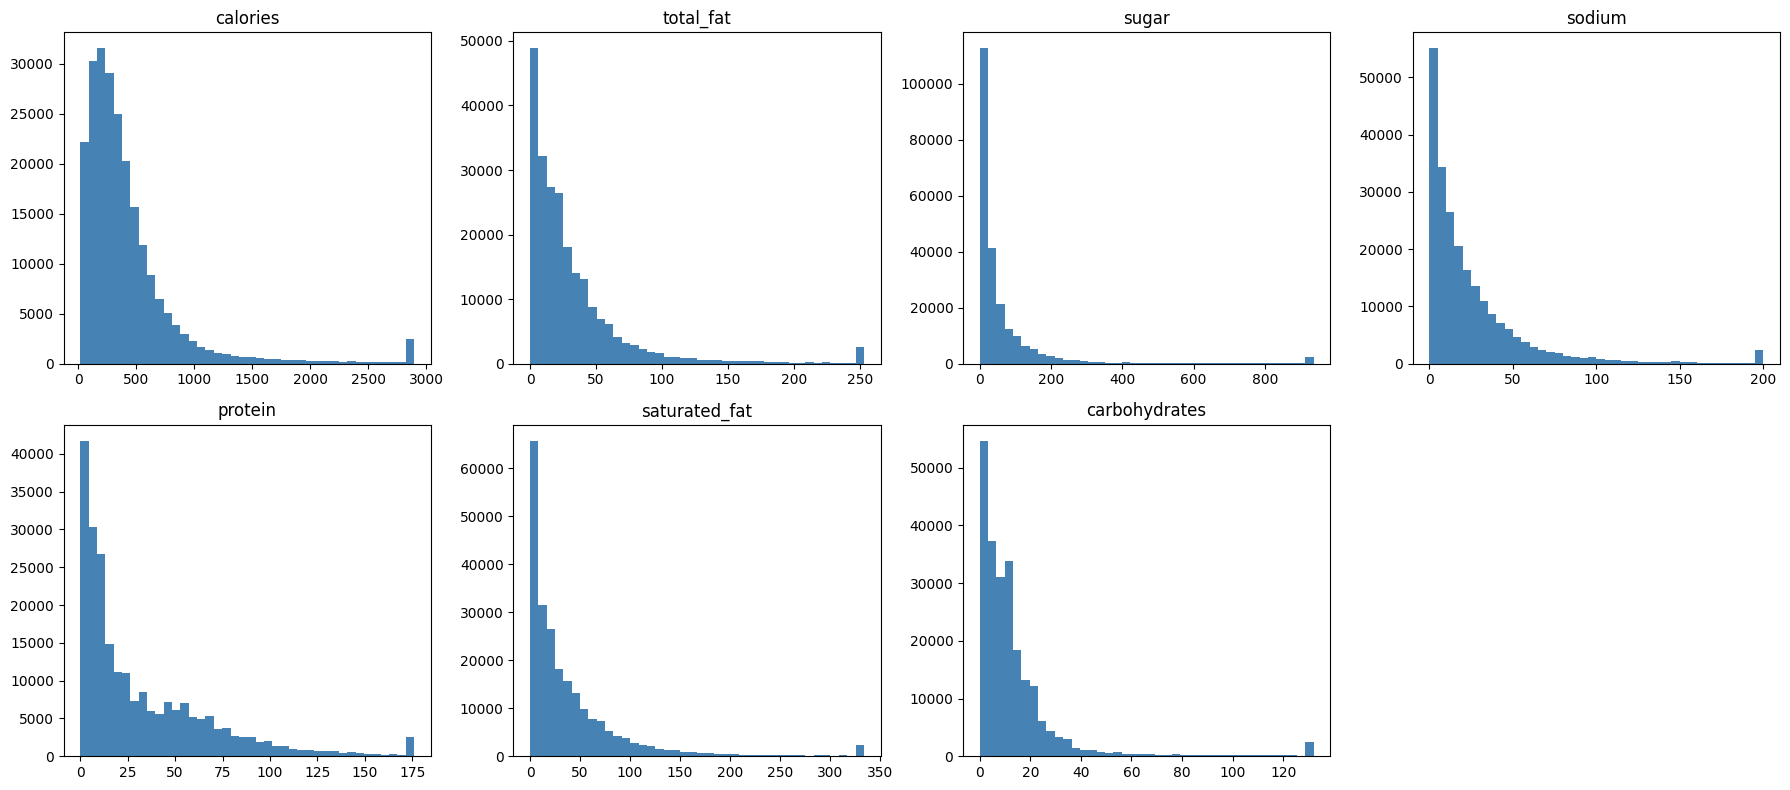

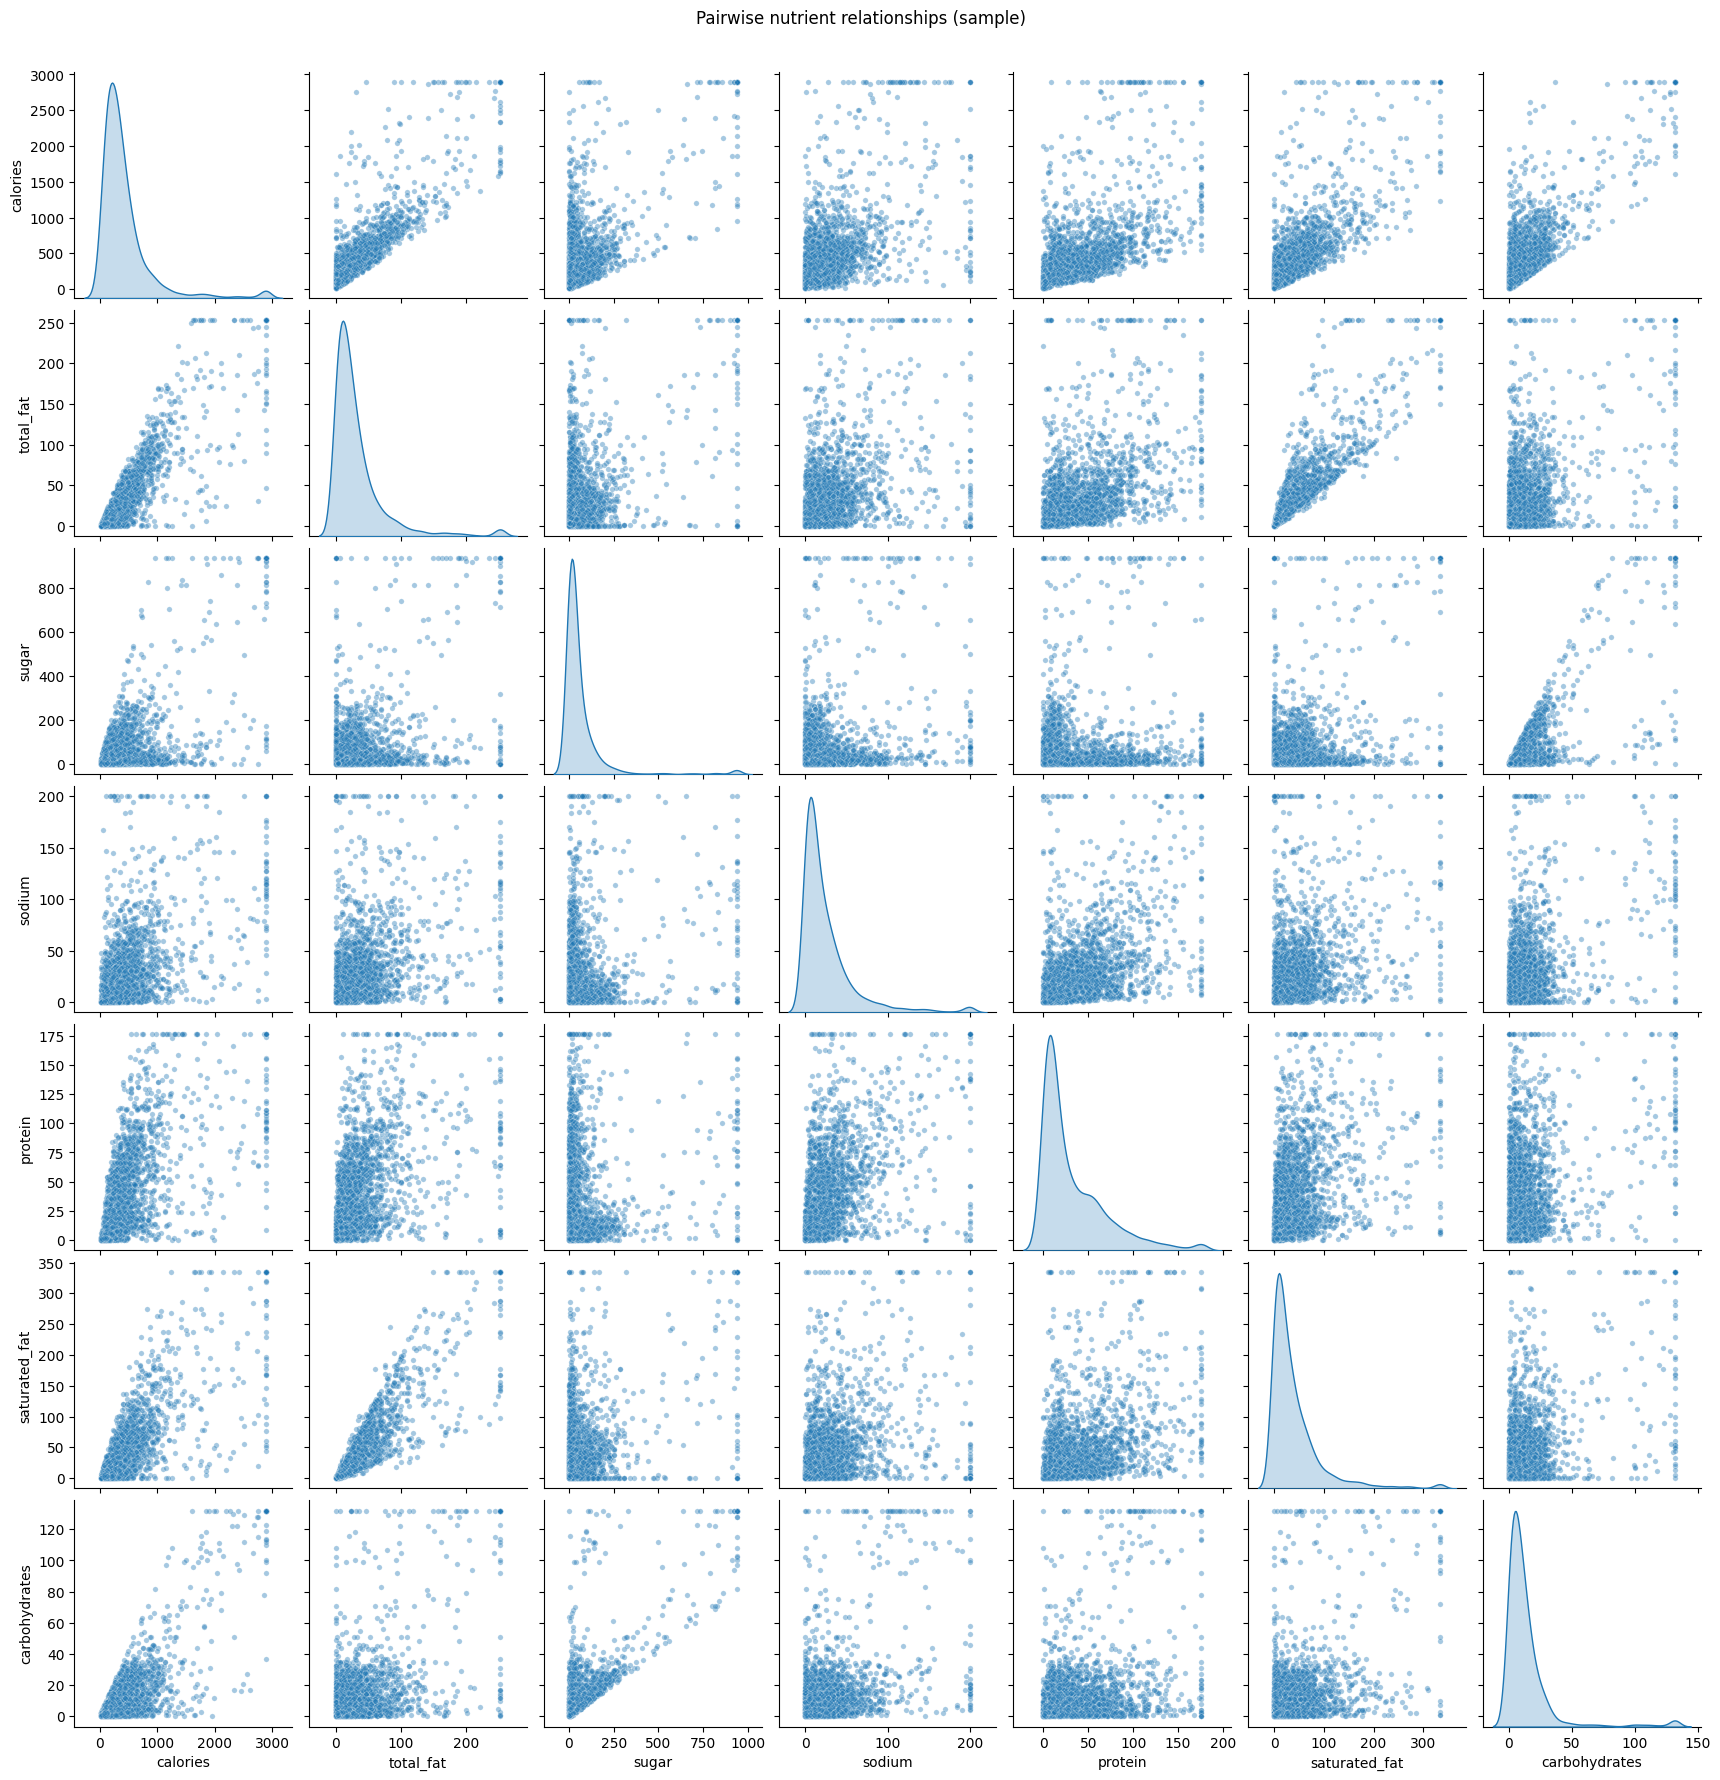

In [7]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # urls
    text = re.sub(r"[^a-z0-9\s]", " ", text)            # punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["food_text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]

# ------------------------------------------------------------
# 2) Drop exact duplicate recipes (same cleaned text) so near-identical
#    rows don't end up split across train/val/test.
# ------------------------------------------------------------
before = len(df)
df = df.drop_duplicates(subset=["clean_text"])
print(f"Dropped {before - len(df)} duplicate recipes")

# ------------------------------------------------------------
# 3) Outlier handling.
#    Food.com nutrition values are user-submitted; a small number of
#    recipes have wildly implausible values (e.g. a tiny reported serving
#    size inflating % daily values into the thousands). Left in, these
#    dominate the MSE loss and the model just learns to predict them.
#    We hard-filter obviously broken rows, then clip the remaining long
#    tail at the 1st/99th percentile per nutrient.
# ------------------------------------------------------------
before = len(df)
df = df[(df["calories"] > 0) & (df["calories"] < 5000)]
print(f"Dropped {before - len(df)} rows with implausible calories")

for col in NUTRIENT_COLS:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)

print(df[NUTRIENT_COLS].describe())

# ------------------------------------------------------------
# 4) Quick EDA
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, NUTRIENT_COLS):
    ax.hist(df[col], bins=40, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

# Pairwise nutrient relationships (sampled -- a full pairplot over ~200k
# rows would be extremely slow to render and add nothing visually).
sample_for_plot = df.sample(n=min(3000, len(df)), random_state=42)
sns.pairplot(sample_for_plot[NUTRIENT_COLS], diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairwise nutrient relationships (sample)", y=1.02)
plt.show()


In [8]:
from sklearn.model_selection import train_test_split

FINAL_COLS = ["id", "name", "clean_text"] + NUTRIENT_COLS
df_final = df[FINAL_COLS].reset_index(drop=True)

train_df, temp_df = train_test_split(df_final, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

train_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("Saved train/val/test splits to", OUTPUT_DIR)


Train: (184428, 10) Val: (23053, 10) Test: (23054, 10)
Saved train/val/test splits to /content/Nutrition_Project/outputs
(every cell from here on reloads these same CSVs instead of re-deriving its own inconsistent split, which was a bug in the original notebook)


# Text Representation

From here on, every cell loads `train.csv` / `val.csv` / `test.csv` from `OUTPUT_DIR` — the single source of truth for the rest of the notebook.

In [9]:
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv(os.path.join(OUTPUT_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(OUTPUT_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(OUTPUT_DIR, "test.csv"))

# ------------------------------------------------------------
# 1) Tokenizer -- fit ONLY on the training text so validation/test
#    vocabulary never leaks into the model.
# ------------------------------------------------------------
VOCAB_SIZE = 20000  # keep the most frequent 20k words; everything else -> <OOV>
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

# ------------------------------------------------------------
# 2) Choose MAX_LEN from the actual length distribution instead of an
#    arbitrary guess, then pad/truncate every split the same way.
# ------------------------------------------------------------
lengths = train_df["clean_text"].str.split().apply(len)
MAX_LEN = max(int(np.percentile(lengths, 95)), 10)
print(f"Sequence length: mean={lengths.mean():.1f}, 95th percentile={MAX_LEN}")

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = texts_to_padded(train_df["clean_text"])
X_val = texts_to_padded(val_df["clean_text"])
X_test = texts_to_padded(test_df["clean_text"])

# ------------------------------------------------------------
# 3) Scale nutrient targets. Calories (0-5000) and %DV nutrients (0-100+)
#    live on very different scales; without scaling, MSE loss is
#    dominated by calories and the model effectively ignores the rest.
#    Fit the scaler on TRAIN ONLY.
# ------------------------------------------------------------
target_scaler = StandardScaler()
y_train = target_scaler.fit_transform(train_df[NUTRIENT_COLS].values)
y_val = target_scaler.transform(val_df[NUTRIENT_COLS].values)
y_test = target_scaler.transform(test_df[NUTRIENT_COLS].values)

# ------------------------------------------------------------
# 4) Persist everything downstream cells need, so every later cell (and
#    the Gradio app) uses the exact same tokenizer/scaler/splits.
# ------------------------------------------------------------
np.save(os.path.join(BASE_DIR, "X_train.npy"), X_train)
np.save(os.path.join(BASE_DIR, "X_val.npy"), X_val)
np.save(os.path.join(BASE_DIR, "X_test.npy"), X_test)
np.save(os.path.join(BASE_DIR, "y_train.npy"), y_train)
np.save(os.path.join(BASE_DIR, "y_val.npy"), y_val)
np.save(os.path.join(BASE_DIR, "y_test.npy"), y_test)

with open(os.path.join(BASE_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)
with open(os.path.join(BASE_DIR, "target_scaler.pkl"), "wb") as f:
    pickle.dump(target_scaler, f)
with open(os.path.join(BASE_DIR, "config.pkl"), "wb") as f:
    pickle.dump({"MAX_LEN": MAX_LEN, "VOCAB_SIZE": VOCAB_SIZE, "NUTRIENT_COLS": NUTRIENT_COLS}, f)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("Saved tokenizer, scaler, config, and padded arrays to", BASE_DIR)


Sequence length: mean=58.6, 95th percentile=123
X_train: (184428, 123) y_train: (184428, 7)
Saved tokenizer, scaler, config, and padded arrays to /content/Nutrition_Project


# Embeddings

Real, pretrained word vectors are downloaded via `gensim` and aligned to the tokenizer's vocabulary to build one embedding matrix per algorithm:

| Name | Pretrained vectors | Dim | Approx. size |
|---|---|---|---|
| GloVe | `glove-wiki-gigaword-100` | 100 | ~128 MB |
| Word2Vec | `word2vec-google-news-300` | 300 | ~1.6 GB |
| FastText | `fasttext-wiki-news-subwords-300` | 300 | ~1 GB |

These only need to download once per session (gensim caches them). If you're iterating quickly or on a slow connection, set `USE_SMALL_MODELS_FOR_DEV = True` below to use a smaller stand-in for all three.

In [10]:
import gensim.downloader as gensim_api

USE_SMALL_MODELS_FOR_DEV = False  # True = faster/smaller download while iterating

if USE_SMALL_MODELS_FOR_DEV:
    EMBEDDING_SOURCES = {
        "glove": "glove-wiki-gigaword-50",
        "word2vec": "glove-wiki-gigaword-50",   # stand-in, same small download
        "fasttext": "glove-wiki-gigaword-50",   # stand-in, same small download
    }
else:
    EMBEDDING_SOURCES = {
        "glove": "glove-wiki-gigaword-100",
        "word2vec": "word2vec-google-news-300",
        "fasttext": "fasttext-wiki-news-subwords-300",
    }

def build_embedding_matrix(word_index, gensim_model_name, vocab_size):
    # Load a pretrained gensim model and build a matrix aligned to our
    # tokenizer's word_index. Words the pretrained model has never seen get
    # a random vector (the same fallback used everywhere in this notebook
    # for genuinely unknown words).
    try:
        kv = gensim_api.load(gensim_model_name)
        emb_dim = kv.vector_size
    except Exception as e:
        print(f"Could not download '{gensim_model_name}' ({e}). "
              "Falling back to random 100-d vectors -- results will be "
              "much worse; this should only happen with no internet access.")
        return np.random.normal(scale=0.6, size=(vocab_size, 100)).astype("float32")

    matrix = np.random.normal(scale=0.6, size=(vocab_size, emb_dim)).astype("float32")
    matrix[0] = np.zeros(emb_dim)  # index 0 is the padding token

    hits = 0
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        if word in kv:
            matrix[idx] = kv[word]
            hits += 1
    denom = min(len(word_index), vocab_size - 1)
    print(f"{gensim_model_name}: {hits}/{denom} vocabulary words found ({hits / denom:.1%})")
    del kv
    return matrix

vocab_size = min(len(tokenizer.word_index) + 1, VOCAB_SIZE)

embedding_matrices = {}
for name, model_name in EMBEDDING_SOURCES.items():
    print(f"\nBuilding '{name}' embedding matrix from {model_name} ...")
    matrix = build_embedding_matrix(tokenizer.word_index, model_name, vocab_size)
    embedding_matrices[name] = matrix
    np.save(os.path.join(OUTPUT_DIR, f"embedding_matrix_{name}.npy"), matrix)

print("\nSaved embedding matrices to", OUTPUT_DIR)



Building 'glove' embedding matrix from glove-wiki-gigaword-100 ...
[==================================================] 100.0% 128.1/128.1MB downloaded
glove-wiki-gigaword-100: 18037/19999 vocabulary words found (90.2%)

Building 'word2vec' embedding matrix from word2vec-google-news-300 ...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
word2vec-google-news-300: 16819/19999 vocabulary words found (84.1%)

Building 'fasttext' embedding matrix from fasttext-wiki-news-subwords-300 ...
[==================================================] 100.0% 958.5/958.4MB downloaded
fasttext-wiki-news-subwords-300: 17624/19999 vocabulary words found (88.1%)

Saved embedding matrices to /content/Nutrition_Project/outputs


# Model Definition

**Architecture:** Embedding → Bidirectional LSTM → Bidirectional LSTM → Dense head → 7 linear outputs (one per nutrient)

For each of the three embedding types (GloVe, Word2Vec, FastText), a separate model is trained with the same architecture, differing only in the pretrained embedding matrix used to initialize the Embedding layer:

1. **Embedding layer** — maps each token id to its pretrained vector (`trainable=False`, `mask_zero=True`).
2. **Bidirectional LSTM(128, return_sequences=True)** — reads the token sequence forwards and backwards.
3. **Bidirectional LSTM(64)** — reduces the sequence to a single fixed-length vector.
4. **Dense(64, relu) + Dropout(0.3)** — regression head.
5. **Dense(7, linear)** — outputs the 7 (scaled) nutrient values.

Loss: **MSE**. Metric: **MAE**. This is the **v1 baseline** model.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_bilstm_regressor(embedding_matrix, max_len, num_outputs, trainable_embedding=False):
    vocab_size, emb_dim = embedding_matrix.shape

    inputs = Input(shape=(max_len,), name="tokens")
    x = Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[embedding_matrix],
        trainable=trainable_embedding,
        mask_zero=True,
    )(inputs)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_outputs, activation="linear", name="nutrients")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model

# Sanity check with the GloVe matrix
sample_model = build_bilstm_regressor(embedding_matrices["glove"], MAX_LEN, len(NUTRIENT_COLS))
sample_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 123)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 123, 100)  │  2,000,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 123)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 123, 256)  │    234,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nutrients (Dense)   │ (None, 7)         │        455 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,407,559 (9.18 MB)

 Trainable params: 407,559 (1.55 MB)

 Non-trainable params: 2,000,000 (7.63 MB)

# Model Training

In [12]:
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 25
BATCH_SIZE = 128

histories = {}
trained_models = {}
test_metrics = {}

for name in EMBEDDING_SOURCES:
    print(f"\n{'=' * 60}\nTraining {name.upper()} BiLSTM regressor\n{'=' * 60}")

    model = build_bilstm_regressor(embedding_matrices[name], MAX_LEN, len(NUTRIENT_COLS))
    ckpt_path = os.path.join(BASE_DIR, f"{name}_bilstm.keras")

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
    ]

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    print(f"Trained in {time.time() - start:.1f}s")

    histories[name] = history
    trained_models[name] = model

    # Evaluate on the held-out test set in ORIGINAL units (inverse-scaled)
    # so MAE is directly interpretable (e.g. "off by 42 calories").
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_true = target_scaler.inverse_transform(y_test)

    mae_per_nutrient = np.mean(np.abs(y_true - y_pred), axis=0)
    overall_mae = mae_per_nutrient.mean()

    test_metrics[name] = {
        "overall_mae": overall_mae,
        **{f"mae_{col}": v for col, v in zip(NUTRIENT_COLS, mae_per_nutrient)},
    }
    print(f"{name.upper()} test MAE (original units): {overall_mae:.2f}")

print("\nAll models trained and saved to", BASE_DIR)



Training GLOVE BiLSTM regressor
Epoch 1/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - loss: 0.8068 - mae: 0.5312 - val_loss: 0.7457 - val_mae: 0.5062
Epoch 2/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - loss: 0.7342 - mae: 0.4976 - val_loss: 0.7005 - val_mae: 0.4758
Epoch 3/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - loss: 0.7038 - mae: 0.4839 - val_loss: 0.6894 - val_mae: 0.4586
Epoch 4/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - loss: 0.6777 - mae: 0.4734 - val_loss: 0.6848 - val_mae: 0.4764
Epoch 5/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - loss: 0.6543 - mae: 0.4648 - val_loss: 0.6971 - val_mae: 0.4652
Epoch 6/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - loss: 0.6263 - mae: 0.4561 - val_loss: 0.6940 - val_mae: 0.4510
Epoch 7/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - loss: 0.5905 - mae: 0.4445 - val_loss: 0.7292 - val_mae: 0.4856
Epoch 8/25
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - loss: 0.5544 - mae: 0.4340 - val_loss: 0.7175 - val_mae

## Fine-Tuning (v2): richer text + upgraded architecture

To push accuracy further, each embedding variant is fine-tuned with two upgrades:

1. **Richer input text** — recipe `steps` are added to `name` + `ingredients` + `description`, giving the model more signal about preparation, quantities, and cooking method.
2. **Upgraded architecture & training regime** — `SpatialDropout1D`, a deeper dense head with `LayerNormalization`, `Huber` loss (more robust to nutrition outliers than plain MSE), and **two-stage training**: a warm-up phase with the pretrained embeddings **frozen**, followed by a fine-tuning phase where the embeddings themselves are unfrozen and adapted to the food/recipe domain (with `ReduceLROnPlateau` for automatic learning-rate decay).

All three embedding variants (GloVe, Word2Vec, FastText) are retrained under this setup, reusing the pretrained embedding matrices already downloaded above — no re-download needed.

In [13]:
# ============================================================
# V2 DATA PREPARATION
# Add recipe STEPS to the existing text representation.
# NO EMBEDDING DOWNLOADS.
# ============================================================

import ast
import re
import numpy as np
import pandas as pd

print("Building V2 text representation...")

def list_to_text(value):
    """Convert Food.com stringified list -> readable text."""
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, (list, tuple)):
            return " ".join(str(x) for x in parsed)
    except Exception:
        pass
    return ""

# ------------------------------------------------------------
# Build an auxiliary table from the already-loaded raw dataset
# ------------------------------------------------------------
raw_aux = df_raw[[
    "id",
    "name",
    "ingredients",
    "steps",
    "description"
]].copy()

raw_aux["ingredients_text_v2"] = raw_aux["ingredients"].apply(list_to_text)
raw_aux["steps_text_v2"] = raw_aux["steps"].apply(list_to_text)

raw_aux["description"] = raw_aux["description"].fillna("").astype(str)

# ------------------------------------------------------------
# Construct richer text
# ------------------------------------------------------------
def build_v2_text(row):
    parts = []

    if str(row["name"]).strip():
        parts.append(str(row["name"]))

    if str(row["ingredients_text_v2"]).strip():
        parts.append("ingredients " + str(row["ingredients_text_v2"]))

    if str(row["steps_text_v2"]).strip():
        parts.append("steps " + str(row["steps_text_v2"]))

    if str(row["description"]).strip():
        parts.append(str(row["description"]))

    return ". ".join(parts)

raw_aux["food_text_v2"] = raw_aux.apply(build_v2_text, axis=1)

# ------------------------------------------------------------
# Clean exactly like the original pipeline
# ------------------------------------------------------------
def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

raw_aux["clean_text_v2"] = raw_aux["food_text_v2"].apply(clean_text_v2)

# ------------------------------------------------------------
# Map richer text onto the SAME saved train/val/test split IDs
# ------------------------------------------------------------
text_lookup = raw_aux.set_index("id")["clean_text_v2"]

train_v2 = train_df.copy()
val_v2 = val_df.copy()
test_v2 = test_df.copy()

train_v2["clean_text_v2"] = train_v2["id"].map(text_lookup)
val_v2["clean_text_v2"] = val_v2["id"].map(text_lookup)
test_v2["clean_text_v2"] = test_v2["id"].map(text_lookup)

assert train_v2["clean_text_v2"].notna().all()
assert val_v2["clean_text_v2"].notna().all()
assert test_v2["clean_text_v2"].notna().all()

print("Train:", len(train_v2))
print("Val  :", len(val_v2))
print("Test :", len(test_v2))

# Show how much information we gained
old_lengths = train_df["clean_text"].str.split().str.len()
new_lengths = train_v2["clean_text_v2"].str.split().str.len()

print("\nOriginal train length:")
print(" mean =", round(old_lengths.mean(), 2))
print(" 95%  =", int(np.percentile(old_lengths, 95)))

print("\nV2 train length:")
print(" mean =", round(new_lengths.mean(), 2))
print(" 95%  =", int(np.percentile(new_lengths, 95)))

print("\nExample V2 text:\n")
print(train_v2["clean_text_v2"].iloc[0][:1500])

Building V2 text representation...
Train: 184428
Val  : 23053
Test : 23054

Original train length:
 mean = 58.61
 95%  = 123

V2 train length:
 mean = 156.2
 95%  = 317

Example V2 text:

chicken curry pies ingredients pie crusts oil ground chicken garlic fresh ginger salt turmeric coriander cumin diced onion chopped tomatoes steps saute onions in oil until tender add garlic and ginger and saute 30 sec add spices and stir together add tomatoes and 1 2 c water stir add chicken and cook through done when the water is cooked out put 2 t of meat on ea piece of pie crust fold over and seal bake at 400 for 10 12 minute since moving to south africa my kids have taken a liking to meat pies so i have been experimenting with my own ideas we all love this one


In [14]:
# ============================================================
# V2 TOKENIZER + TRANSFER EXISTING EMBEDDING MATRICES
# NO INTERNET / NO GENSIM DOWNLOAD
# ============================================================

import os
import pickle
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

V2_VOCAB_SIZE = 25000

# A little longer because we now include recipe steps.
V2_MAX_LEN = 180

# ------------------------------------------------------------
# New tokenizer trained ONLY on V2 TRAIN text
# ------------------------------------------------------------
tokenizer_v2 = Tokenizer(
    num_words=V2_VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer_v2.fit_on_texts(train_v2["clean_text_v2"])

def make_sequences_v2(texts):
    seqs = tokenizer_v2.texts_to_sequences(texts)
    return pad_sequences(
        seqs,
        maxlen=V2_MAX_LEN,
        padding="post",
        truncating="post"
    )

X_train_v2 = make_sequences_v2(train_v2["clean_text_v2"])
X_val_v2   = make_sequences_v2(val_v2["clean_text_v2"])
X_test_v2  = make_sequences_v2(test_v2["clean_text_v2"])

print("X_train_v2:", X_train_v2.shape)
print("X_val_v2  :", X_val_v2.shape)
print("X_test_v2 :", X_test_v2.shape)

# ------------------------------------------------------------
# Reuse the ORIGINAL target scaler
# ------------------------------------------------------------
y_train_v2 = target_scaler.transform(
    train_v2[NUTRIENT_COLS].values
).astype("float32")

y_val_v2 = target_scaler.transform(
    val_v2[NUTRIENT_COLS].values
).astype("float32")

y_test_v2 = target_scaler.transform(
    test_v2[NUTRIENT_COLS].values
).astype("float32")

# ------------------------------------------------------------
# Transfer already-downloaded pretrained embeddings
# ------------------------------------------------------------
def transfer_embedding_matrix(
    old_tokenizer,
    new_tokenizer,
    old_matrix,
    new_vocab_size
):
    old_word_index = old_tokenizer.word_index
    new_word_index = new_tokenizer.word_index

    emb_dim = old_matrix.shape[1]

    rng = np.random.default_rng(42)

    # Smaller random initialization for genuinely new words.
    new_matrix = rng.normal(
        loc=0.0,
        scale=0.05,
        size=(new_vocab_size, emb_dim)
    ).astype("float32")

    # Padding token
    new_matrix[0] = 0.0

    transferred = 0

    for word, new_idx in new_word_index.items():

        if new_idx >= new_vocab_size:
            continue

        old_idx = old_word_index.get(word)

        if old_idx is not None and old_idx < old_matrix.shape[0]:
            new_matrix[new_idx] = old_matrix[old_idx]
            transferred += 1

    print(
        f"Transferred {transferred:,} vectors "
        f"into {new_vocab_size:,} vocabulary slots "
        f"({transferred / max(1, min(len(new_word_index), new_vocab_size-1)):.1%})"
    )

    return new_matrix


new_vocab_size = min(
    len(tokenizer_v2.word_index) + 1,
    V2_VOCAB_SIZE
)

embedding_matrices_v2 = {}

for name in ["glove", "word2vec", "fasttext"]:

    # Prefer in-memory matrices.
    if name in embedding_matrices:
        old_matrix = embedding_matrices[name]

    # Otherwise load from the files already created.
    else:
        old_matrix = np.load(
            os.path.join(
                OUTPUT_DIR,
                f"embedding_matrix_{name}.npy"
            )
        )

    print(f"\n{name.upper()}")

    embedding_matrices_v2[name] = transfer_embedding_matrix(
        tokenizer,
        tokenizer_v2,
        old_matrix,
        new_vocab_size
    )

    np.save(
        os.path.join(
            OUTPUT_DIR,
            f"embedding_matrix_{name}_v2.npy"
        ),
        embedding_matrices_v2[name]
    )

# ------------------------------------------------------------
# Save V2 preprocessing
# ------------------------------------------------------------
np.save(os.path.join(BASE_DIR, "X_train_v2.npy"), X_train_v2)
np.save(os.path.join(BASE_DIR, "X_val_v2.npy"), X_val_v2)
np.save(os.path.join(BASE_DIR, "X_test_v2.npy"), X_test_v2)

np.save(os.path.join(BASE_DIR, "y_train_v2.npy"), y_train_v2)
np.save(os.path.join(BASE_DIR, "y_val_v2.npy"), y_val_v2)
np.save(os.path.join(BASE_DIR, "y_test_v2.npy"), y_test_v2)

with open(os.path.join(BASE_DIR, "tokenizer_v2.pkl"), "wb") as f:
    pickle.dump(tokenizer_v2, f)

with open(os.path.join(BASE_DIR, "config_v2.pkl"), "wb") as f:
    pickle.dump({
        "MAX_LEN": V2_MAX_LEN,
        "VOCAB_SIZE": V2_VOCAB_SIZE,
        "NUTRIENT_COLS": NUTRIENT_COLS
    }, f)

print("\nV2 preprocessing complete.")
print("No pretrained embedding model was downloaded.")

X_train_v2: (184428, 180)
X_val_v2  : (23053, 180)
X_test_v2 : (23054, 180)

GLOVE
Transferred 19,999 vectors into 25,000 vocabulary slots (80.0%)

WORD2VEC
Transferred 19,999 vectors into 25,000 vocabulary slots (80.0%)

FASTTEXT
Transferred 19,999 vectors into 25,000 vocabulary slots (80.0%)

V2 preprocessing complete.
No pretrained embedding model was downloaded.


In [15]:
# ============================================================
# V2 BiLSTM TRAINING
# Uses existing pretrained embedding matrices.
# NO GloVe / Word2Vec / FastText downloads.
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.losses import Huber

print("TensorFlow:", tf.__version__)

# ------------------------------------------------------------
# Better architecture
# ------------------------------------------------------------
def build_better_bilstm(
    embedding_matrix,
    max_len,
    num_outputs
):
    vocab_size, emb_dim = embedding_matrix.shape

    inputs = Input(
        shape=(max_len,),
        dtype="int32",
        name="tokens"
    )

    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[embedding_matrix],
        trainable=False,
        mask_zero=True,
        name="pretrained_embedding"
    )(inputs)

    x = SpatialDropout1D(0.15)(embedding)

    x = Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.10
        )
    )(x)

    x = Bidirectional(
        LSTM(
            64,
            dropout=0.10
        )
    )(x)

    x = Dense(128, activation="relu")(x)
    x = LayerNormalization()(x)
    x = Dropout(0.25)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)

    outputs = Dense(
        num_outputs,
        activation="linear",
        name="nutrients"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(
            learning_rate=3e-4,
            clipnorm=1.0
        ),
        loss=Huber(delta=1.0),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model


# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------
V2_WARMUP_EPOCHS = 4
V2_FINETUNE_EPOCHS = 10
V2_BATCH_SIZE = 128

histories_v2 = {}
trained_models_v2 = {}
test_metrics_v2 = {}

# ------------------------------------------------------------
# Train each pretrained embedding variant
# ------------------------------------------------------------
for name in ["glove", "word2vec", "fasttext"]:

    print("\n" + "=" * 70)
    print(f"TRAINING V2 {name.upper()} BiLSTM")
    print("=" * 70)

    model = build_better_bilstm(
        embedding_matrices_v2[name],
        V2_MAX_LEN,
        len(NUTRIENT_COLS)
    )

    best_path = os.path.join(
        BASE_DIR,
        f"{name}_bilstm_v2.keras"
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            best_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1
        )
    ]

    start = time.time()

    # --------------------------------------------------------
    # Stage 1: pretrained embeddings frozen
    # --------------------------------------------------------
    print("\nStage 1: frozen embeddings")

    history1 = model.fit(
        X_train_v2,
        y_train_v2,
        validation_data=(X_val_v2, y_val_v2),
        epochs=V2_WARMUP_EPOCHS,
        batch_size=V2_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # --------------------------------------------------------
    # Stage 2: fine-tune pretrained embeddings
    # --------------------------------------------------------
    print("\nStage 2: fine-tuning embeddings")

    model.get_layer("pretrained_embedding").trainable = True

    model.compile(
        optimizer=Adam(
            learning_rate=5e-5,
            clipnorm=1.0
        ),
        loss=Huber(delta=1.0),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    history2 = model.fit(
        X_train_v2,
        y_train_v2,
        validation_data=(X_val_v2, y_val_v2),
        epochs=V2_FINETUNE_EPOCHS,
        batch_size=V2_BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - start

    trained_models_v2[name] = model
    histories_v2[name] = (history1, history2)

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------
    pred_scaled = model.predict(
        X_test_v2,
        batch_size=512,
        verbose=0
    )

    pred = target_scaler.inverse_transform(pred_scaled)
    true = target_scaler.inverse_transform(y_test_v2)

    pred = np.clip(pred, 0, None)

    mae = np.mean(
        np.abs(true - pred),
        axis=0
    )

    test_metrics_v2[name] = {
        f"mae_{col}": float(value)
        for col, value in zip(NUTRIENT_COLS, mae)
    }

    print(f"\n{name.upper()} V2 completed in {elapsed / 60:.1f} minutes")

    print("\nPer-nutrient MAE:")
    for col, value in zip(NUTRIENT_COLS, mae):
        print(f"  {col:18s}: {value:.3f}")

print("\nV2 training completed.")

TensorFlow: 2.20.0

TRAINING V2 GLOVE BiLSTM

Stage 1: frozen embeddings
Epoch 1/4
1440/1441 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.2909 - mae: 0.5894
Epoch 1: val_loss improved from None to 0.24234, saving model to /content/Nutrition_Project/glove_bilstm_v2.keras

Epoch 1: finished saving model to /content/Nutrition_Project/glove_bilstm_v2.keras
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 102s 62ms/step - loss: 0.2684 - mae: 0.5505 - val_loss: 0.2423 - val_mae: 0.4963 - learning_rate: 3.0000e-04
Epoch 2/4
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2474 - mae: 0.5114
Epoch 2: val_loss improved from 0.24234 to 0.23116, saving model to /content/Nutrition_Project/glove_bilstm_v2.keras

Epoch 2: finished saving model to /content/Nutrition_Project/glove_bilstm_v2.keras
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 137s 60ms/step - loss: 0.2456 - mae: 0.5075 - val_loss: 0.2312 - val_mae: 0.4753 - learning_rate: 3.0000e-04
Epoch 3/4
1441/1441 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2395 - mae: 0.4954

# Optional: BERT-based regressor

This section fine-tunes a small regression head on top of a **frozen** DistilBERT encoder as an alternative text representation.

Extracting DistilBERT embeddings for the full ~230K-recipe dataset is slow on CPU. `ENABLE_BERT_MODEL` defaults to `False` — set it to `True` (ideally with a GPU runtime) to run this section. `BERT_SAMPLE_SIZE` lets you try it on a manageable subset first.

In [16]:
ENABLE_BERT_MODEL = False
BERT_SAMPLE_SIZE = 20000   # recipes to use for the (slow) BERT feature extraction

if ENABLE_BERT_MODEL:
    from transformers import DistilBertTokenizerFast, TFDistilBertModel
    from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
    from tensorflow.keras.models import Model
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping

    bert_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
    bert_encoder = TFDistilBertModel.from_pretrained("distilbert-base-uncased")
    bert_encoder.trainable = False  # frozen -- we only train the head on top

    BERT_MAX_LEN = 32

    def encode_texts(texts, batch_size=64):
        # Run frozen DistilBERT over `texts` in batches and return the
        # per-token hidden states, ready to feed into a BiLSTM head.
        all_hidden = []
        texts = list(texts)
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = bert_tokenizer(
                batch, padding="max_length", truncation=True,
                max_length=BERT_MAX_LEN, return_tensors="tf",
            )
            out = bert_encoder(enc["input_ids"], attention_mask=enc["attention_mask"])
            all_hidden.append(out.last_hidden_state.numpy())
            if (i // batch_size) % 20 == 0:
                print(f"  encoded {min(i + batch_size, len(texts))}/{len(texts)}")
        return np.concatenate(all_hidden, axis=0)

    # Subsample train/val/test for BERT feature extraction -- a full pass
    # over the whole dataset on CPU can take hours.
    bert_train_df = train_df.sample(n=min(BERT_SAMPLE_SIZE, len(train_df)), random_state=42)
    bert_val_df = val_df.sample(n=min(3000, len(val_df)), random_state=42)
    bert_test_df = test_df.sample(n=min(3000, len(test_df)), random_state=42)

    print("Encoding text with DistilBERT (this may take a while)...")
    X_train_bert = encode_texts(bert_train_df["clean_text"])
    X_val_bert = encode_texts(bert_val_df["clean_text"])
    X_test_bert = encode_texts(bert_test_df["clean_text"])

    y_train_bert = target_scaler.transform(bert_train_df[NUTRIENT_COLS].values)
    y_val_bert = target_scaler.transform(bert_val_df[NUTRIENT_COLS].values)
    y_test_bert = target_scaler.transform(bert_test_df[NUTRIENT_COLS].values)

    inputs = Input(shape=(BERT_MAX_LEN, 768), name="bert_hidden_states")
    x = Bidirectional(LSTM(64))(inputs)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(len(NUTRIENT_COLS), activation="linear")(x)

    bert_model = Model(inputs, outputs)
    bert_model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])

    history_bert = bert_model.fit(
        X_train_bert, y_train_bert,
        validation_data=(X_val_bert, y_val_bert),
        epochs=EPOCHS,
        batch_size=64,
        callbacks=[EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    )

    bert_model.save(os.path.join(BASE_DIR, "distilbert_bilstm.keras"))

    y_pred_bert = target_scaler.inverse_transform(bert_model.predict(X_test_bert, verbose=0))
    y_true_bert = target_scaler.inverse_transform(y_test_bert)
    mae_bert = np.mean(np.abs(y_true_bert - y_pred_bert), axis=0)

    test_metrics["distilbert"] = {
        "overall_mae": mae_bert.mean(),
        **{f"mae_{col}": v for col, v in zip(NUTRIENT_COLS, mae_bert)},
    }
    trained_models["distilbert"] = bert_model
    histories["distilbert"] = history_bert
    print("DistilBERT+BiLSTM test MAE (original units):", mae_bert.mean())
else:
    print("ENABLE_BERT_MODEL is False -- skipping the DistilBERT variant. "
          "Set it to True above to run it (needs `transformers` and, ideally, a GPU).")


ENABLE_BERT_MODEL is False -- skipping the DistilBERT variant. Set it to True above to run it (needs `transformers` and, ideally, a GPU).


# Model Evaluation & Comparison

## Baseline (v1) results

Test-set MAE (original units) by model:

          overall_mae
word2vec    53.674132
fasttext    54.345546
glove       55.118788


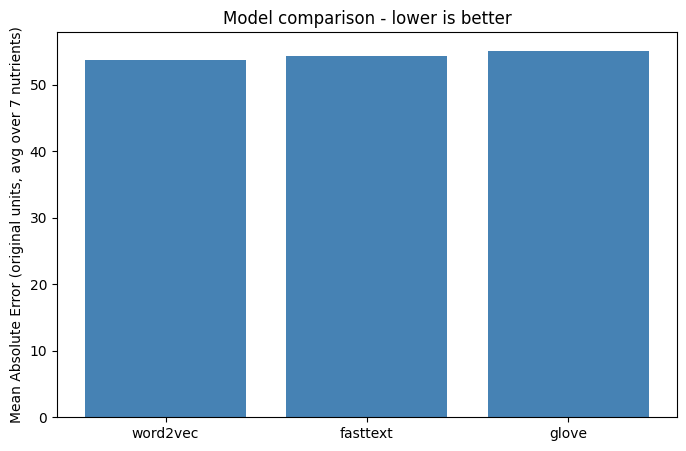

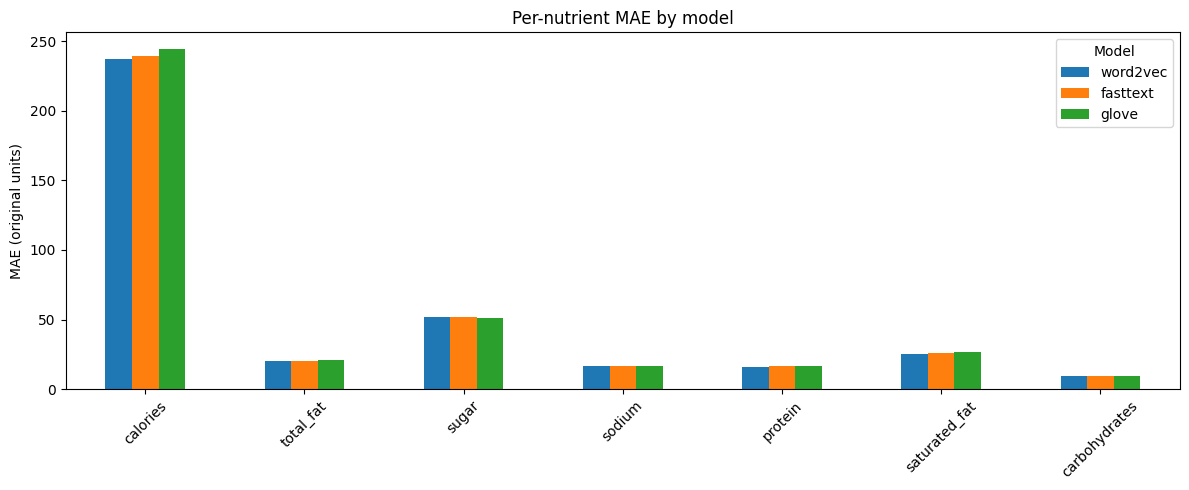

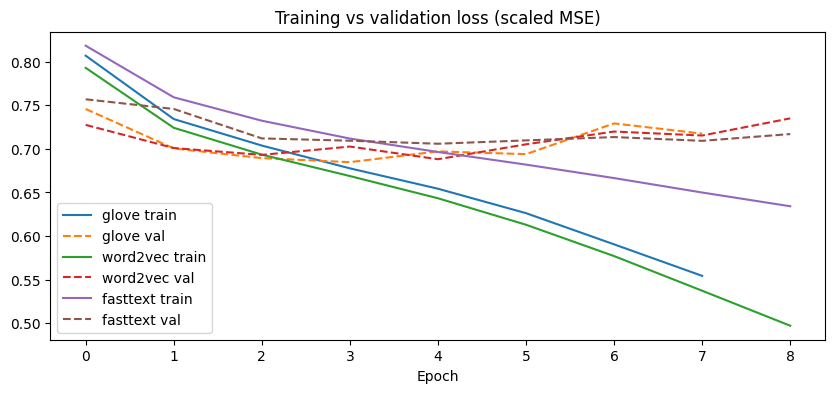

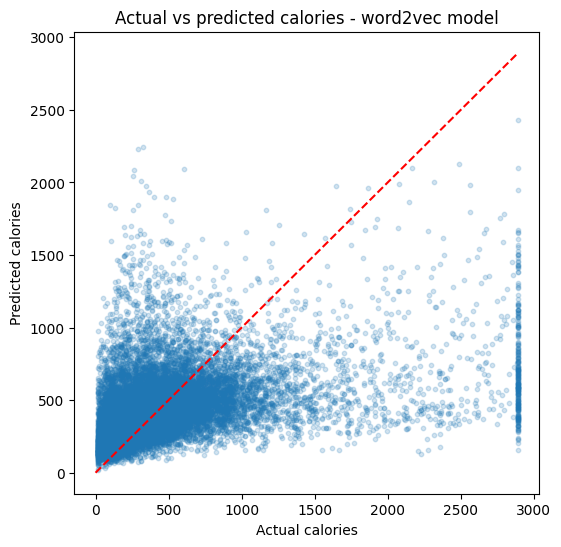


Best model on test MAE: word2vec


In [17]:
metrics_df = pd.DataFrame(test_metrics).T.sort_values("overall_mae")
print("Test-set MAE (original units) by model:\n")
print(metrics_df[["overall_mae"]])

# Overall MAE comparison
plt.figure(figsize=(8, 5))
plt.bar(metrics_df.index, metrics_df["overall_mae"], color="steelblue")
plt.ylabel("Mean Absolute Error (original units, avg over 7 nutrients)")
plt.title("Model comparison - lower is better")
plt.show()

# Per-nutrient MAE breakdown for every trained model
mae_cols = [f"mae_{c}" for c in NUTRIENT_COLS]
metrics_df[mae_cols].T.plot(kind="bar", figsize=(12, 5))
plt.ylabel("MAE (original units)")
plt.title("Per-nutrient MAE by model")
plt.xticks(range(len(NUTRIENT_COLS)), NUTRIENT_COLS, rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(10, 4))
for name, h in histories.items():
    if "loss" in h.history:
        plt.plot(h.history["loss"], label=f"{name} train")
        plt.plot(h.history["val_loss"], label=f"{name} val", linestyle="--")
plt.title("Training vs validation loss (scaled MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Actual vs. predicted calories for the best model
best_name = metrics_df.index[0]
best_model = trained_models[best_name]
y_pred_best = target_scaler.inverse_transform(best_model.predict(X_test, verbose=0))
y_true_best = target_scaler.inverse_transform(y_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_best[:, 0], y_pred_best[:, 0], alpha=0.2, s=10)
lims = [0, max(y_true_best[:, 0].max(), y_pred_best[:, 0].max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual calories")
plt.ylabel("Predicted calories")
plt.title(f"Actual vs predicted calories - {best_name} model")
plt.show()

print(f"\nBest model on test MAE: {best_name}")


## Fine-tuned (v2) results — full test set

The v2 models are evaluated on the same 23,054-recipe held-out test set used for the baseline, so the numbers below are directly comparable to the v1 results above.

In [18]:
# ============================================================
# V2: SIDE-BY-SIDE MODEL COMPARISON
# Actual vs GloVe vs Word2Vec vs FastText
# ============================================================

import numpy as np
import pandas as pd

NUM_SAMPLES_TO_SHOW = 30

# ------------------------------------------------------------
# Make sure test_v2 exists
# ------------------------------------------------------------
if "test_v2" not in globals():
    test_v2 = pd.read_csv(
        os.path.join(OUTPUT_DIR, "test.csv")
    )

# ------------------------------------------------------------
# Convert true targets back to original nutrient units
# ------------------------------------------------------------
y_true_original = target_scaler.inverse_transform(
    y_test_v2
)

# ------------------------------------------------------------
# Select samples
# ------------------------------------------------------------
sample_indices = np.arange(
    min(NUM_SAMPLES_TO_SHOW, len(test_v2))
)

# ------------------------------------------------------------
# Generate predictions for every model once
# ------------------------------------------------------------
all_predictions = {}

print("=" * 100)
print("GENERATING PREDICTIONS FOR ALL V2 MODELS")
print("=" * 100)

for model_name, model in trained_models_v2.items():

    print(f"Predicting with {model_name}...")

    pred_scaled = model.predict(
        X_test_v2,
        batch_size=512,
        verbose=0
    )

    pred = target_scaler.inverse_transform(
        pred_scaled
    )

    # Nutritional values cannot be negative
    pred = np.clip(
        pred,
        0,
        None
    )

    all_predictions[model_name] = pred

print("\nPredictions generated successfully.")

# ------------------------------------------------------------
# Create one table per nutrient
# ------------------------------------------------------------
for nutrient_idx, nutrient in enumerate(NUTRIENT_COLS):

    print("\n" + "=" * 100)
    print(f"{nutrient.upper()} — ACTUAL VS ALL MODELS")
    print("=" * 100)

    rows = []

    for idx in sample_indices:

        row = {
            "Food": test_v2.iloc[idx]["name"],
            "Actual": round(
                float(
                    y_true_original[idx, nutrient_idx]
                ),
                1
            )
        }

        # Add each model prediction
        for model_name, predictions in all_predictions.items():

            row[model_name.upper()] = round(
                float(
                    predictions[idx, nutrient_idx]
                ),
                1
            )

        rows.append(row)

    nutrient_comparison = pd.DataFrame(rows)

    display(nutrient_comparison)

    # --------------------------------------------------------
    # MAE for the displayed 30 samples
    # --------------------------------------------------------
    actual_values = y_true_original[
        sample_indices,
        nutrient_idx
    ]

    print("\nMAE on displayed samples:")

    for model_name, predictions in all_predictions.items():

        predicted_values = predictions[
            sample_indices,
            nutrient_idx
        ]

        mae = np.mean(
            np.abs(
                actual_values - predicted_values
            )
        )

        print(
            f"  {model_name:12s}: {mae:.2f}"
        )

GENERATING PREDICTIONS FOR ALL V2 MODELS
Predicting with glove...
Predicting with word2vec...
Predicting with fasttext...

Predictions generated successfully.

CALORIES — ACTUAL VS ALL MODELS


,Food,Actual,GLOVE,WORD2VEC,FASTTEXT
0,braised lamb shanks with barley,762.9,929.1,917.6,943.1
1,creole grits,328.1,283.5,275.3,261.6
2,simple taco casserole for picky eaters and kids,475.0,453.0,440.6,428.3
3,grilled prosciutto wrapped scallops,83.9,250.8,277.8,243.5
4,pan fried potatoes with bacon and parmesan,1015.5,380.9,437.9,475.2
5,french chicken and beef soup,272.8,562.0,466.6,505.5
6,chili man s engine 3 green chili,365.1,712.9,695.4,639.2
7,cherry tomatoes in herb marinade,182.8,149.7,122.1,120.4
8,cheddar stuffed potatoes,424.0,411.6,400.8,420.3
9,fragrant east indian basmati rice,212.3,326.3,326.5,343.2



MAE on displayed samples:
  glove       : 205.79
  word2vec    : 218.14
  fasttext    : 224.95

TOTAL_FAT — ACTUAL VS ALL MODELS


,Food,Actual,GLOVE,WORD2VEC,FASTTEXT
0,braised lamb shanks with barley,54.0,94.2,93.5,91.2
1,creole grits,24.0,21.1,16.8,16.7
2,simple taco casserole for picky eaters and kids,36.0,33.8,31.0,27.9
3,grilled prosciutto wrapped scallops,10.0,19.5,20.7,20.4
4,pan fried potatoes with bacon and parmesan,22.0,28.4,28.9,31.1
5,french chicken and beef soup,27.0,48.8,39.1,42.1
6,chili man s engine 3 green chili,35.0,60.4,59.0,49.9
7,cherry tomatoes in herb marinade,28.0,9.7,7.6,7.2
8,cheddar stuffed potatoes,37.0,35.7,32.6,32.8
9,fragrant east indian basmati rice,6.0,18.9,18.9,18.6



MAE on displayed samples:
  glove       : 13.61
  word2vec    : 13.85
  fasttext    : 14.39

SUGAR — ACTUAL VS ALL MODELS


...


MAE on displayed samples:
  glove       : 12.87
  word2vec    : 12.04
  fasttext    : 12.36

SATURATED_FAT — ACTUAL VS ALL MODELS


,Food,Actual,GLOVE,WORD2VEC,FASTTEXT
0,braised lamb shanks with barley,63.0,113.8,107.2,102.8
1,creole grits,26.0,23.8,16.5,17.6
2,simple taco casserole for picky eaters and kids,64.0,42.2,35.2,32.0
3,grilled prosciutto wrapped scallops,4.0,20.5,20.6,21.0
4,pan fried potatoes with bacon and parmesan,16.0,36.6,37.1,38.5
5,french chicken and beef soup,25.0,59.5,48.0,52.9
6,chili man s engine 3 green chili,38.0,78.5,74.2,67.1
7,cherry tomatoes in herb marinade,12.0,8.0,4.0,5.2
8,cheddar stuffed potatoes,62.0,51.1,44.2,42.2
9,fragrant east indian basmati rice,3.0,17.6,20.8,17.3



MAE on displayed samples:
  glove       : 21.70
  word2vec    : 22.37
  fasttext    : 20.90

CARBOHYDRATES — ACTUAL VS ALL MODELS


,Food,Actual,GLOVE,WORD2VEC,FASTTEXT
0,braised lamb shanks with barley,12.0,6.8,7.4,10.0
1,creole grits,12.0,8.9,10.9,10.0
2,simple taco casserole for picky eaters and kids,9.0,10.3,10.7,12.5
3,grilled prosciutto wrapped scallops,0.0,3.0,3.8,2.4
4,pan fried potatoes with bacon and parmesan,66.0,13.1,17.7,18.5
5,french chicken and beef soup,1.0,8.3,8.7,8.3
6,chili man s engine 3 green chili,3.0,14.7,13.9,15.1
7,cherry tomatoes in herb marinade,1.0,5.3,4.4,4.0
8,cheddar stuffed potatoes,11.0,11.0,12.6,13.9
9,fragrant east indian basmati rice,13.0,14.3,14.5,15.4



MAE on displayed samples:
  glove       : 8.72
  word2vec    : 9.45
  fasttext    : 9.64


In [19]:
# ============================================================
# V2 — COMPLETE MODEL VISUALIZATION
# Uses the FULL HELD-OUT TEST SET
# Models: GloVe, Word2Vec, FastText
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
if "all_predictions" not in globals():
    all_predictions = {}

    print("Generating predictions for all V2 models...")

    for model_name, model in trained_models_v2.items():

        pred_scaled = model.predict(
            X_test_v2,
            batch_size=512,
            verbose=0
        )

        pred = target_scaler.inverse_transform(
            pred_scaled
        )

        # Nutrition values cannot be negative
        pred = np.clip(pred, 0, None)

        all_predictions[model_name] = pred

# True values in original units
y_true_original = target_scaler.inverse_transform(
    y_test_v2
)

print("Prediction arrays ready.")
print("Test samples:", len(y_true_original))
print("Nutrients:", NUTRIENT_COLS)

Prediction arrays ready.
Test samples: 23054
Nutrients: ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']


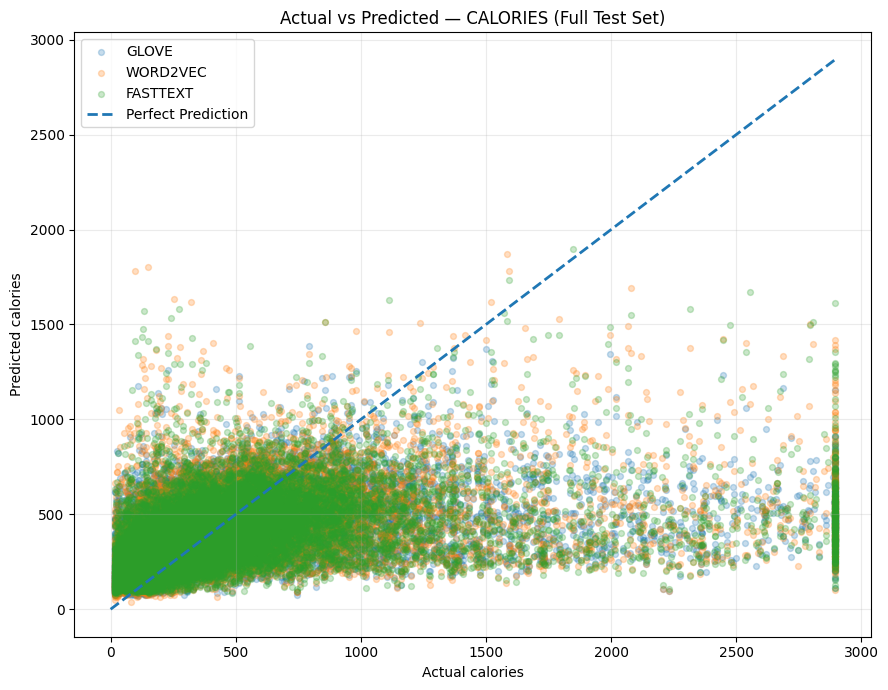

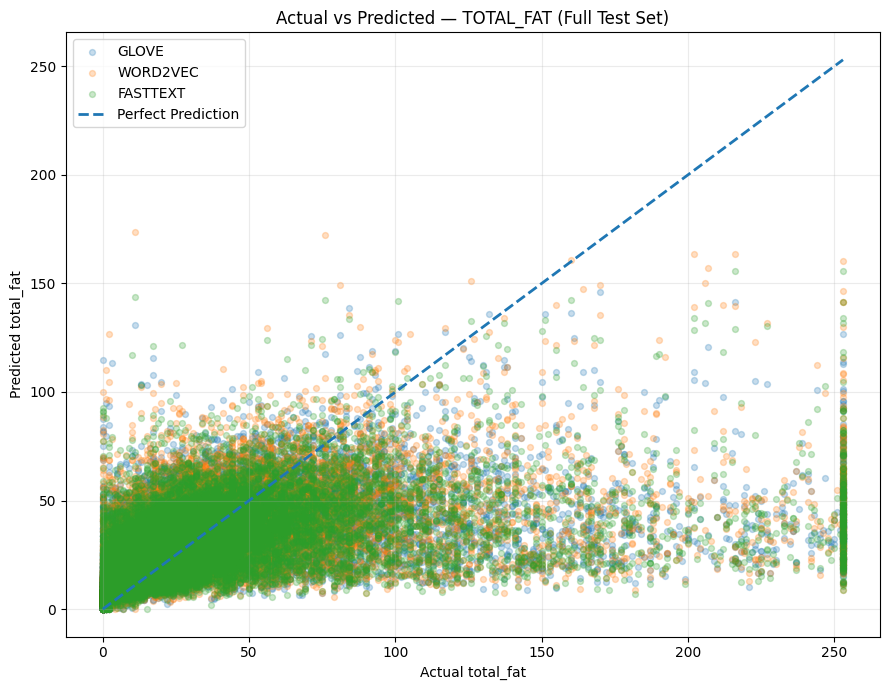

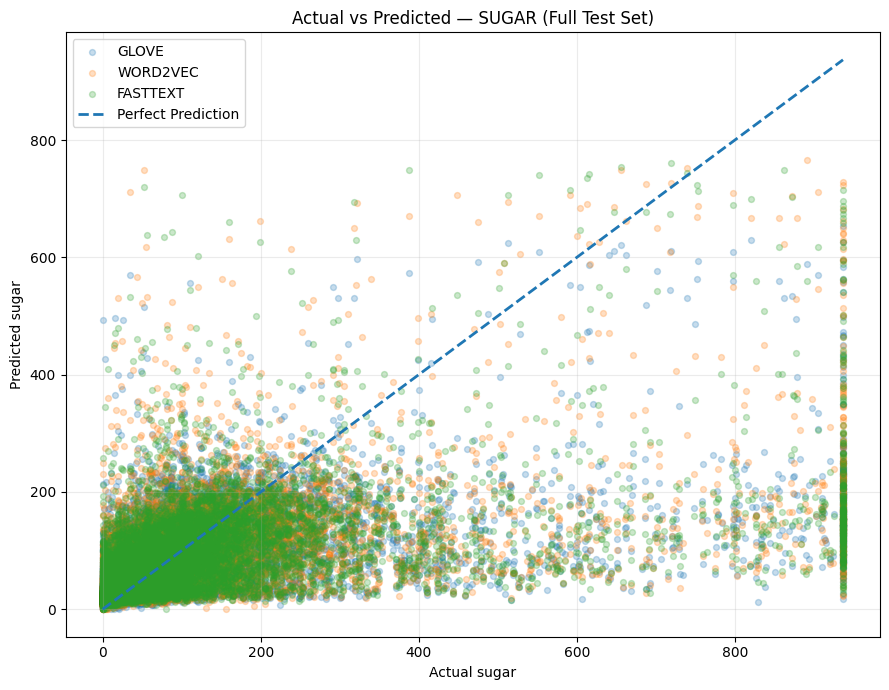

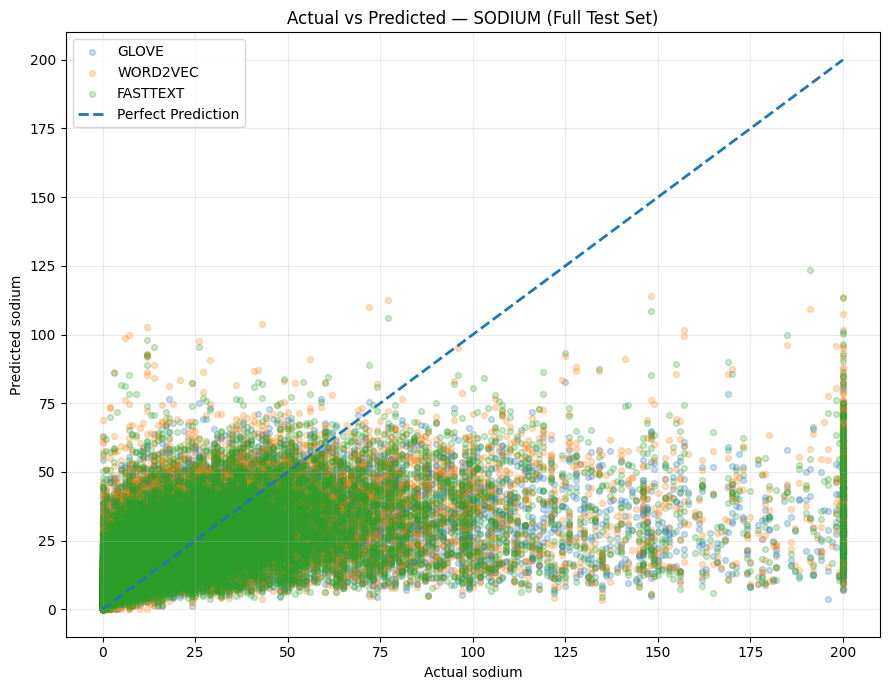

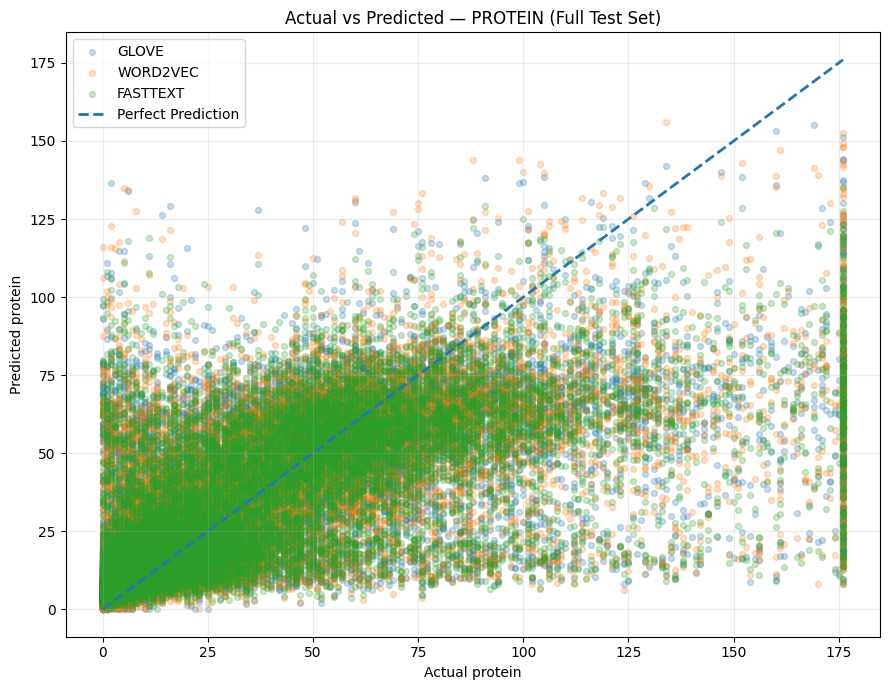

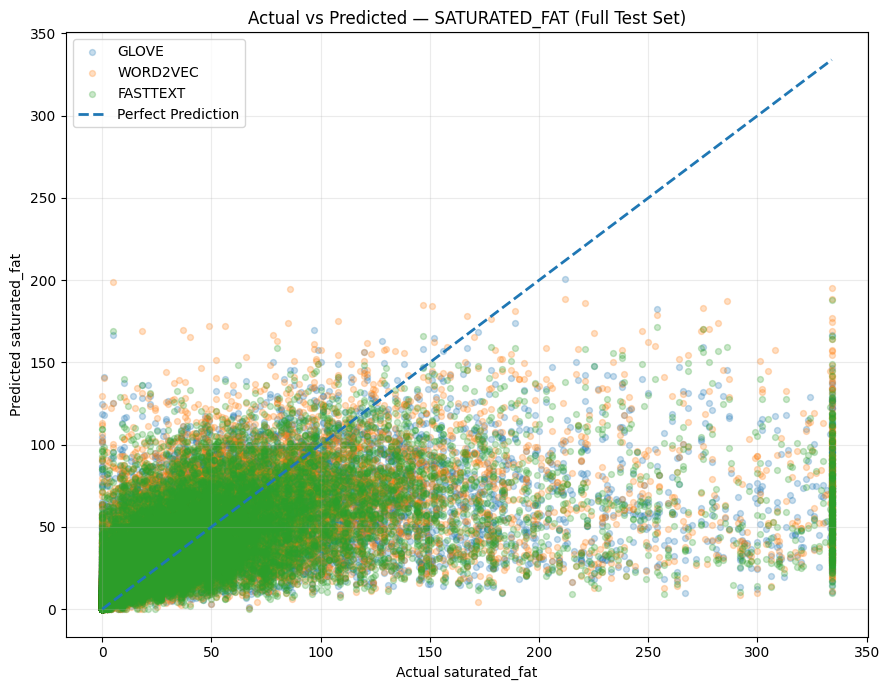

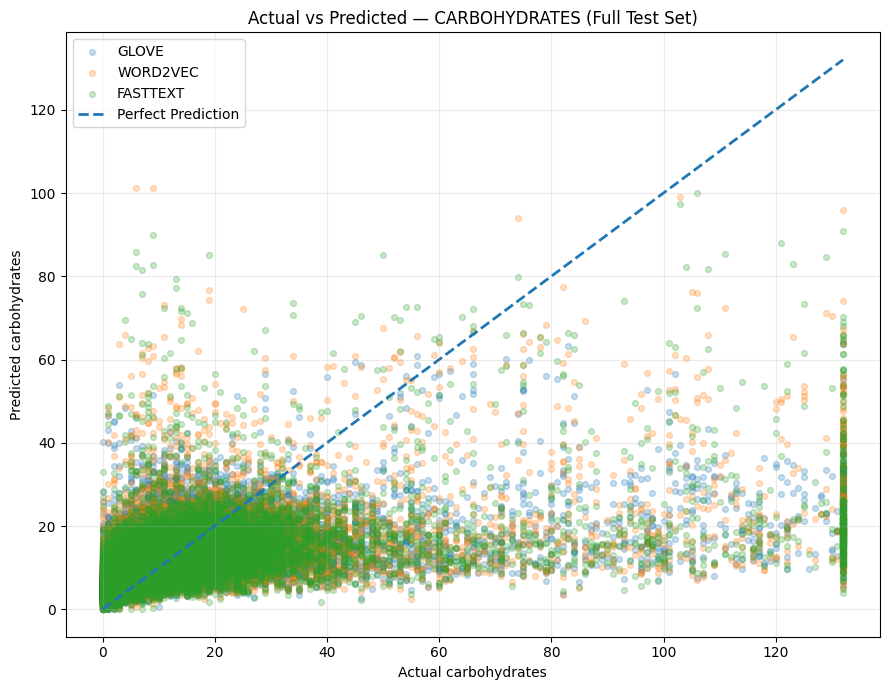

In [20]:
# ============================================================
# GRAPH 1 — ACTUAL vs PREDICTED SCATTER PLOTS
# One graph per nutrient
# ============================================================

for nutrient_idx, nutrient in enumerate(NUTRIENT_COLS):

    plt.figure(figsize=(9, 7))

    actual = y_true_original[:, nutrient_idx]

    # Determine overall plotting range
    all_values = [actual]

    for pred in all_predictions.values():
        all_values.append(pred[:, nutrient_idx])

    max_value = max(
        np.max(values)
        for values in all_values
    )

    # Plot each model
    for model_name, predictions in all_predictions.items():

        predicted = predictions[:, nutrient_idx]

        plt.scatter(
            actual,
            predicted,
            alpha=0.25,
            s=18,
            label=model_name.upper()
        )

    # Perfect prediction line
    plt.plot(
        [0, max_value],
        [0, max_value],
        linestyle="--",
        linewidth=2,
        label="Perfect Prediction"
    )

    plt.xlabel(f"Actual {nutrient}")
    plt.ylabel(f"Predicted {nutrient}")
    plt.title(
        f"Actual vs Predicted — {nutrient.upper()} "
        f"(Full Test Set)"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


FULL TEST SET MAE:


,glove,word2vec,fasttext
calories,221.059998,216.139999,215.789993
total_fat,19.090000,18.719999,18.650000
sugar,46.169998,45.040001,45.380001
sodium,16.309999,15.690000,15.500000
protein,15.730000,15.430000,15.590000
saturated_fat,24.040001,23.570000,23.559999
carbohydrates,8.590000,8.330000,8.270000


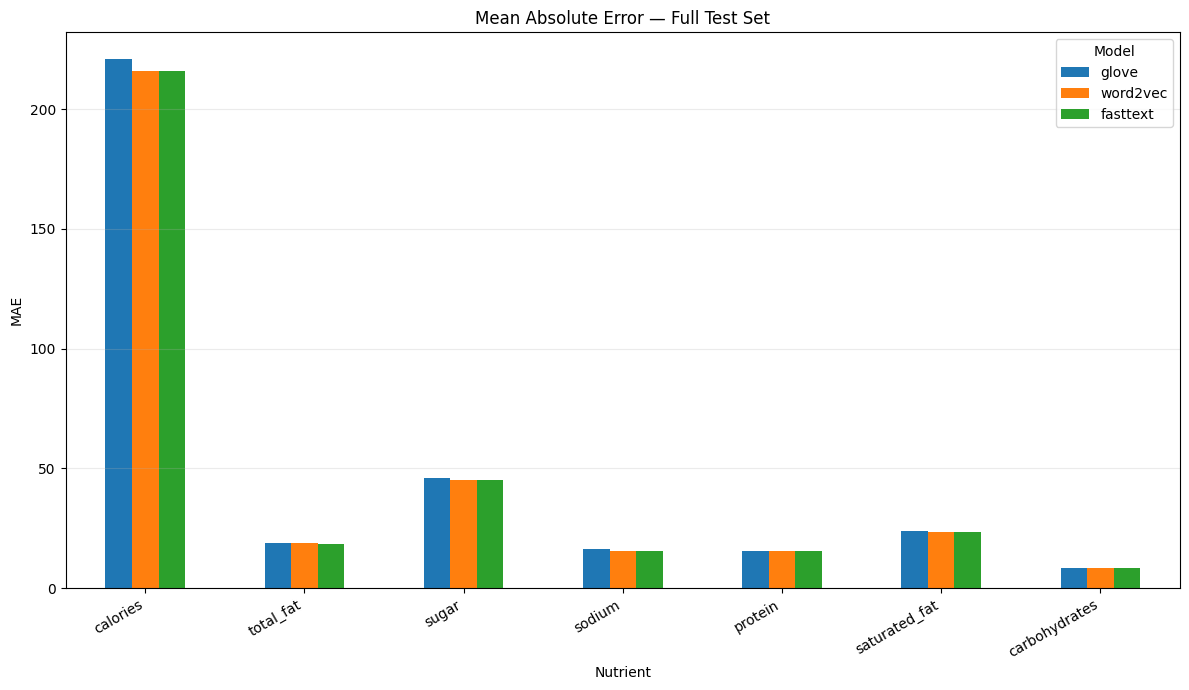

In [21]:
# ============================================================
# GRAPH 2 — MAE COMPARISON
# Full TEST SET
# ============================================================

mae_results = {}

for model_name, predictions in all_predictions.items():

    mae_results[model_name] = np.mean(
        np.abs(
            y_true_original - predictions
        ),
        axis=0
    )

mae_df = pd.DataFrame(
    mae_results,
    index=NUTRIENT_COLS
)

print("FULL TEST SET MAE:")
display(mae_df.round(2))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

ax = mae_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "Mean Absolute Error — Full Test Set"
)

plt.xlabel("Nutrient")
plt.ylabel("MAE")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    title="Model"
)

plt.tight_layout()
plt.show()

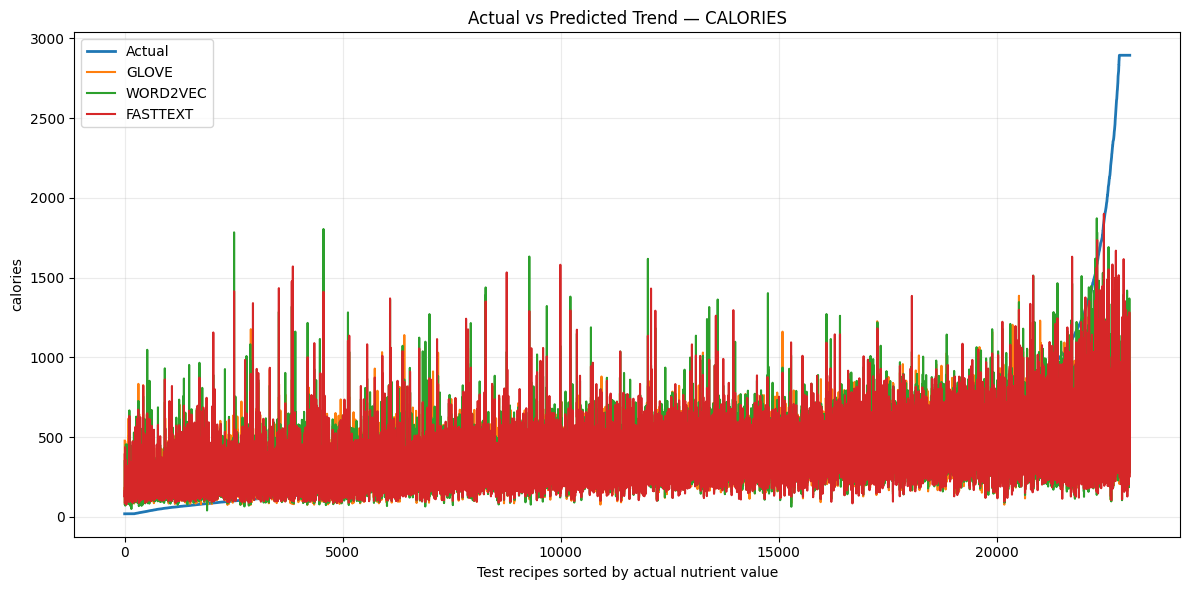

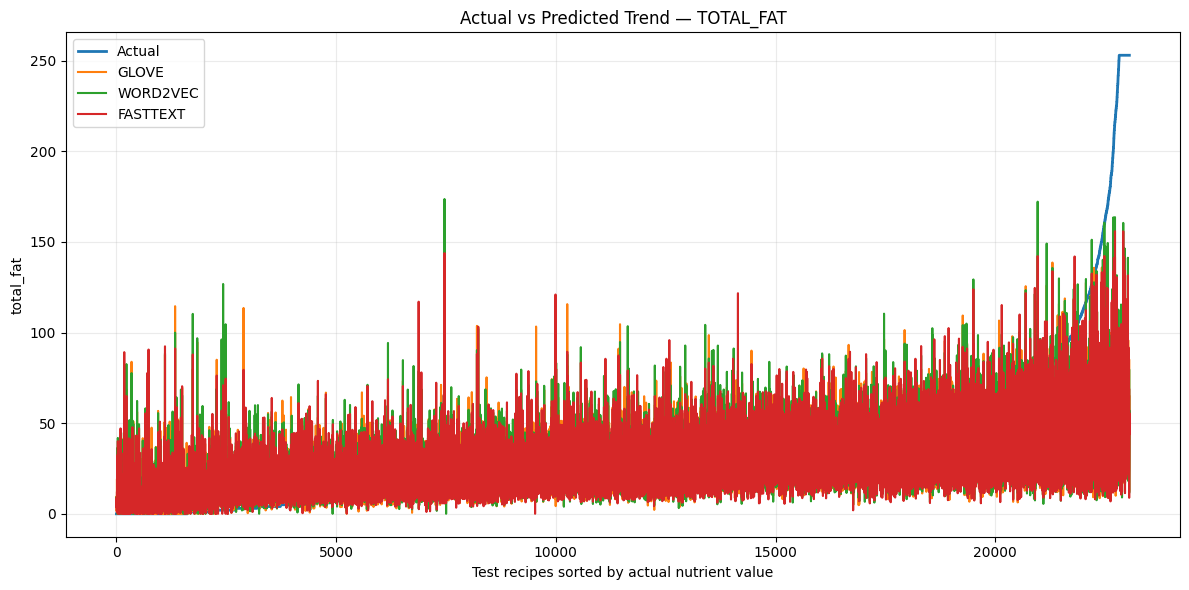

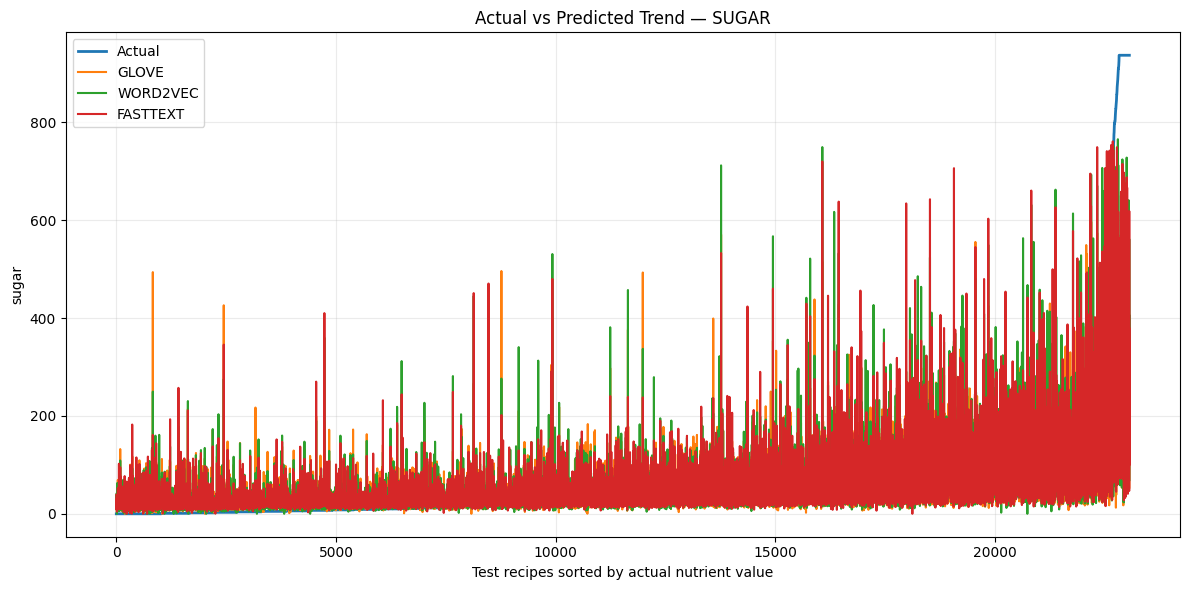

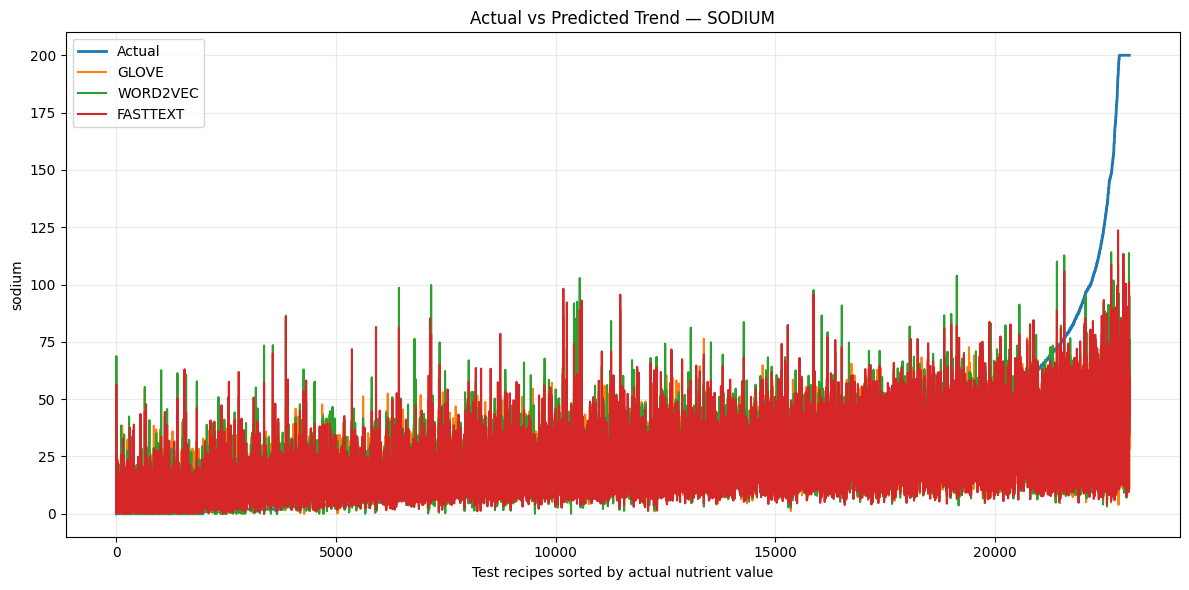

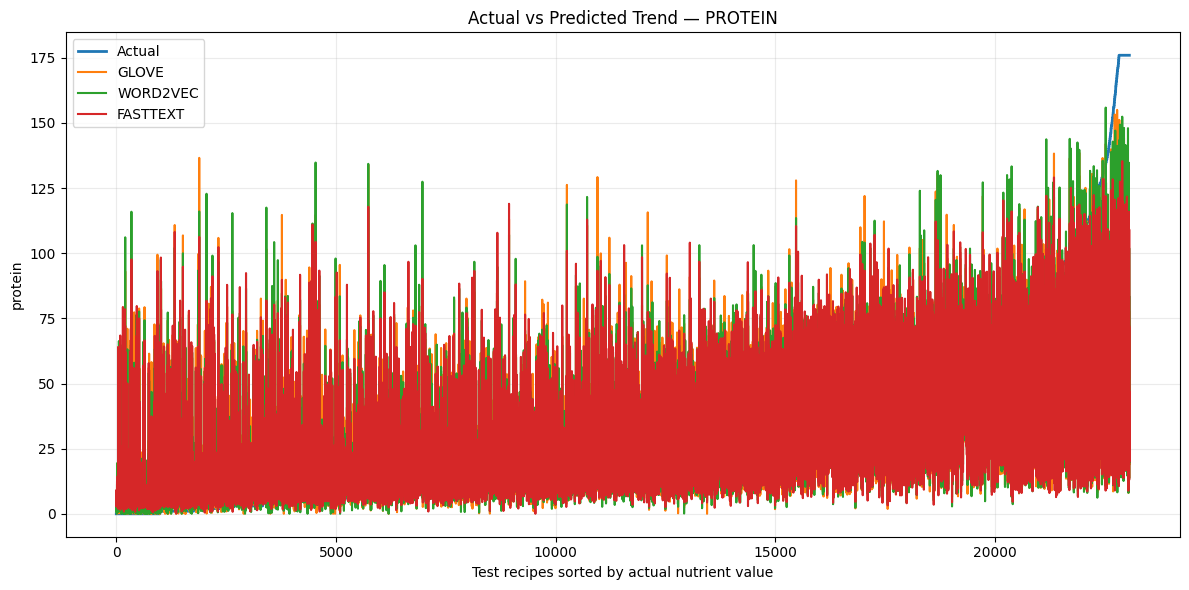

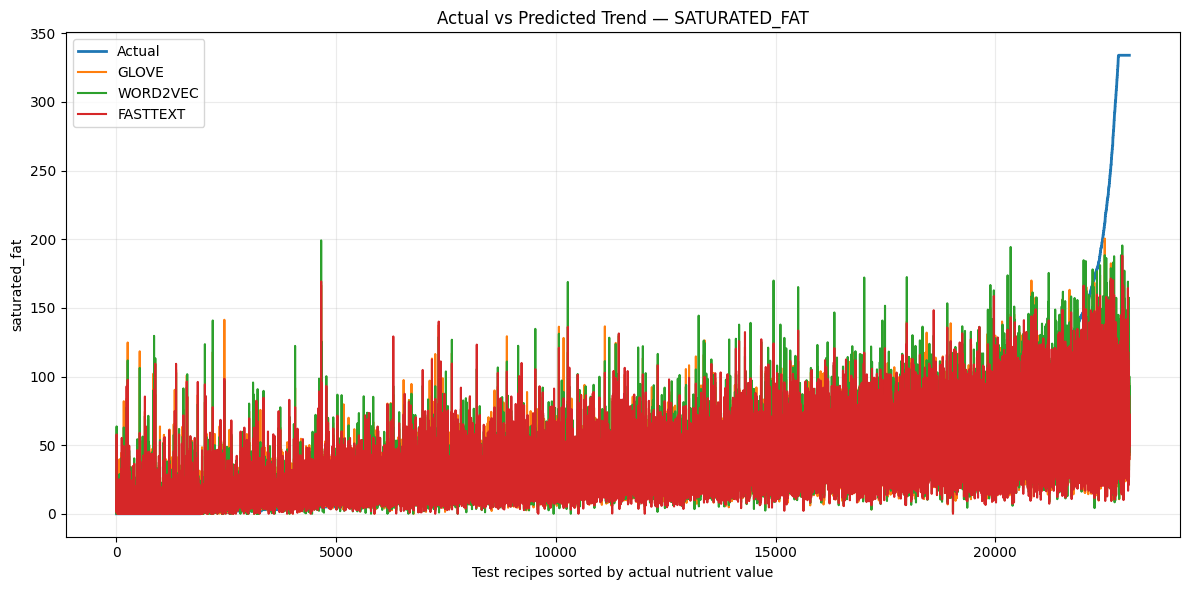

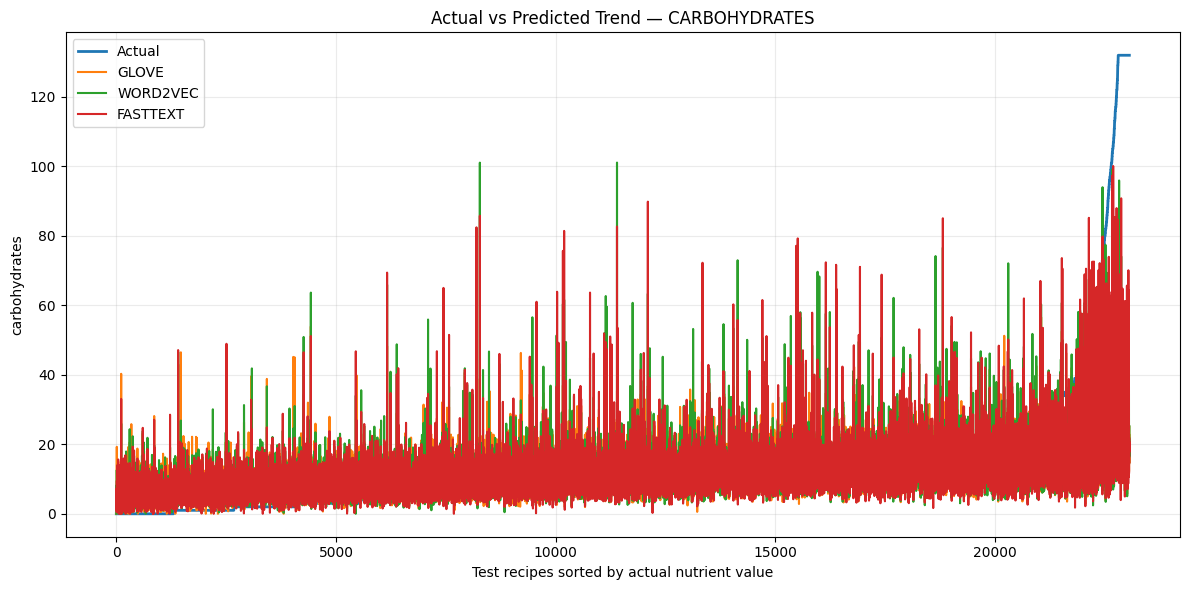

In [22]:
# ============================================================
# GRAPH 3 — ACTUAL vs PREDICTED MEDIAN/MEAN TREND
# Shows regression toward the average
# ============================================================

for nutrient_idx, nutrient in enumerate(NUTRIENT_COLS):

    actual = y_true_original[:, nutrient_idx]

    # Sort recipes by actual nutrient value
    order = np.argsort(actual)

    sorted_actual = actual[order]

    plt.figure(figsize=(12, 6))

    plt.plot(
        sorted_actual,
        label="Actual",
        linewidth=2
    )

    for model_name, predictions in all_predictions.items():

        sorted_predicted = predictions[
            order,
            nutrient_idx
        ]

        plt.plot(
            sorted_predicted,
            label=model_name.upper(),
            linewidth=1.5
        )

    plt.title(
        f"Actual vs Predicted Trend — {nutrient.upper()}"
    )

    plt.xlabel(
        "Test recipes sorted by actual nutrient value"
    )

    plt.ylabel(nutrient)

    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

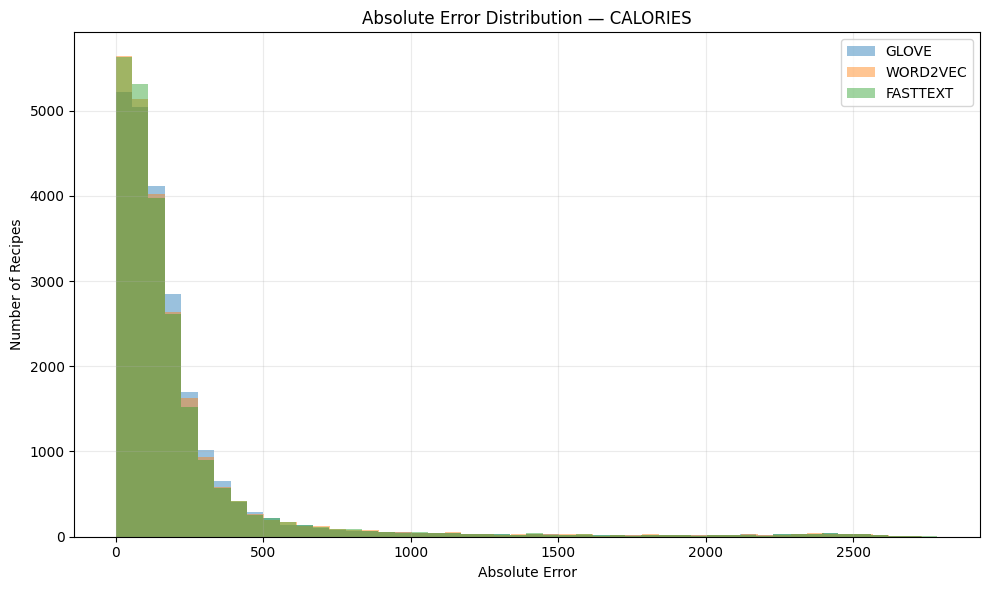

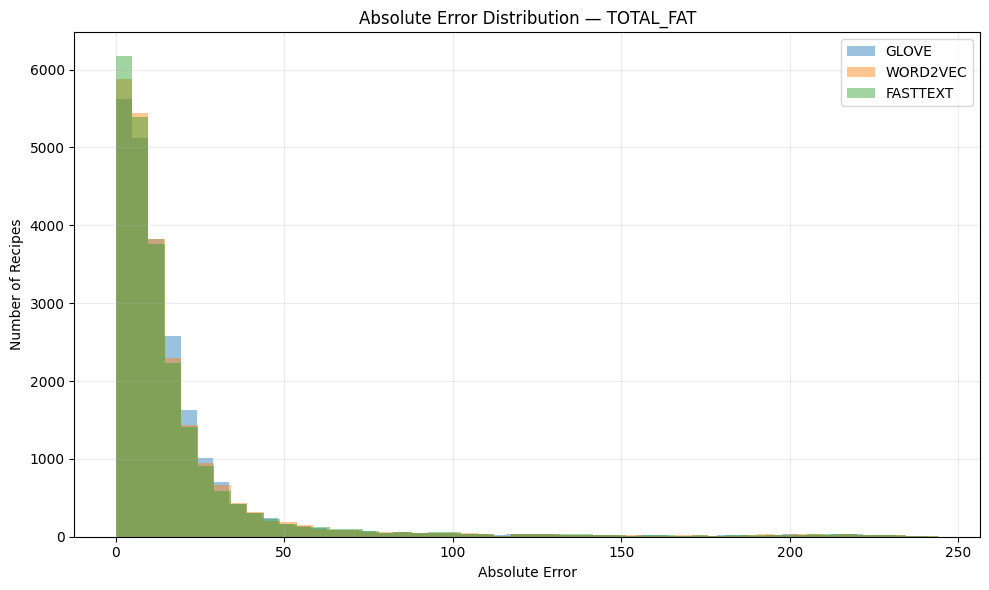

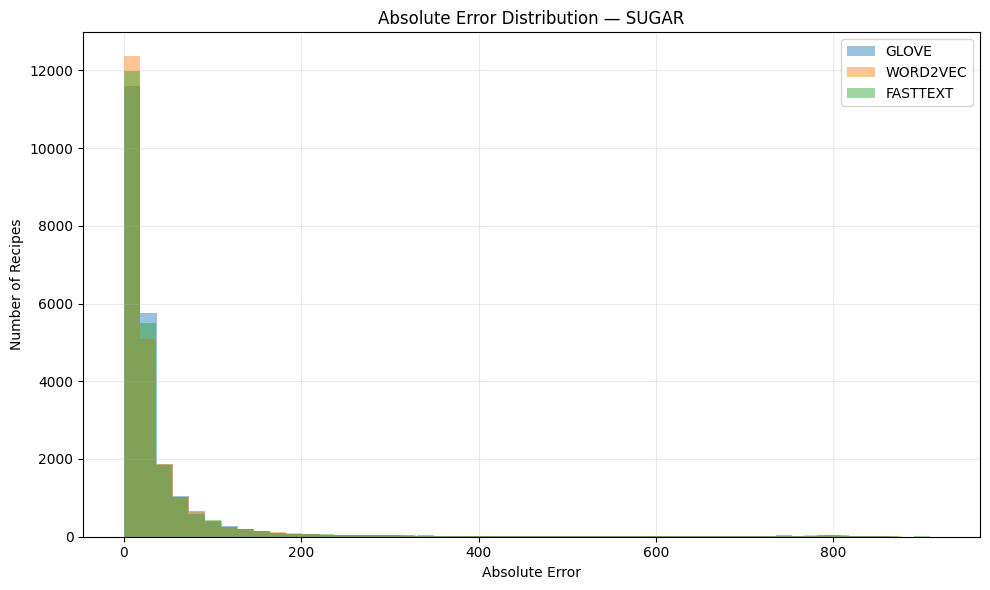

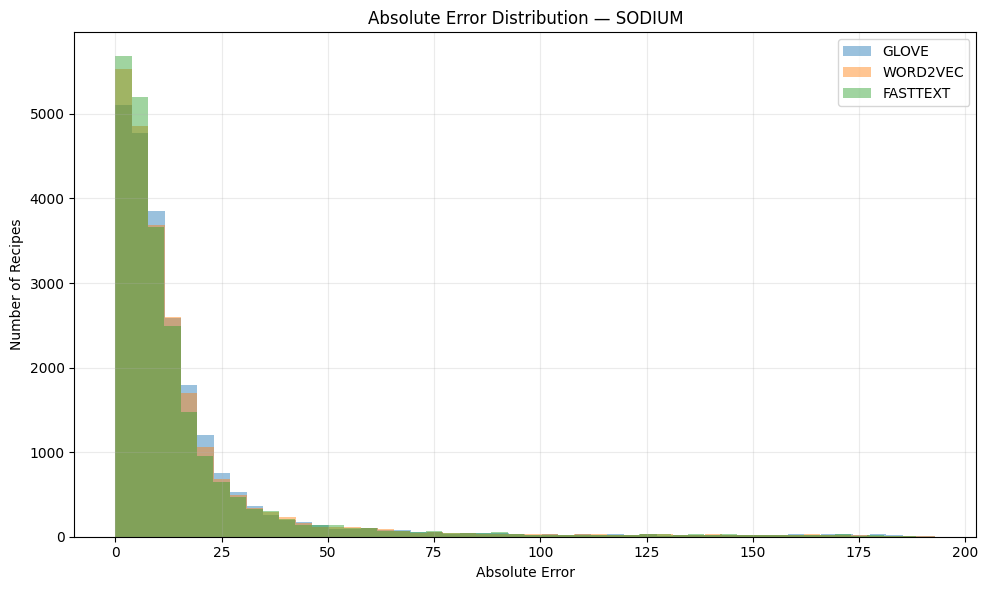

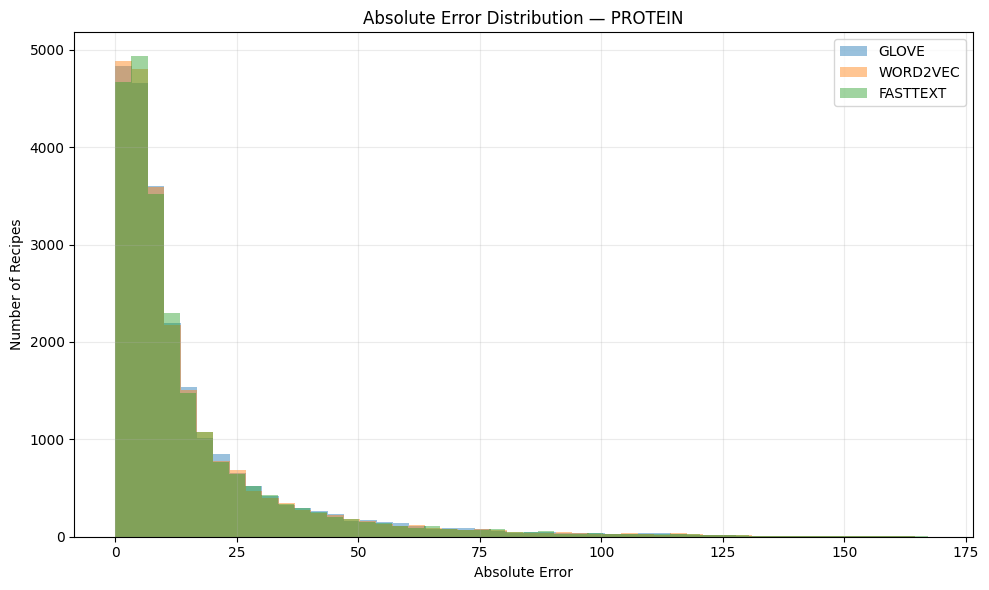

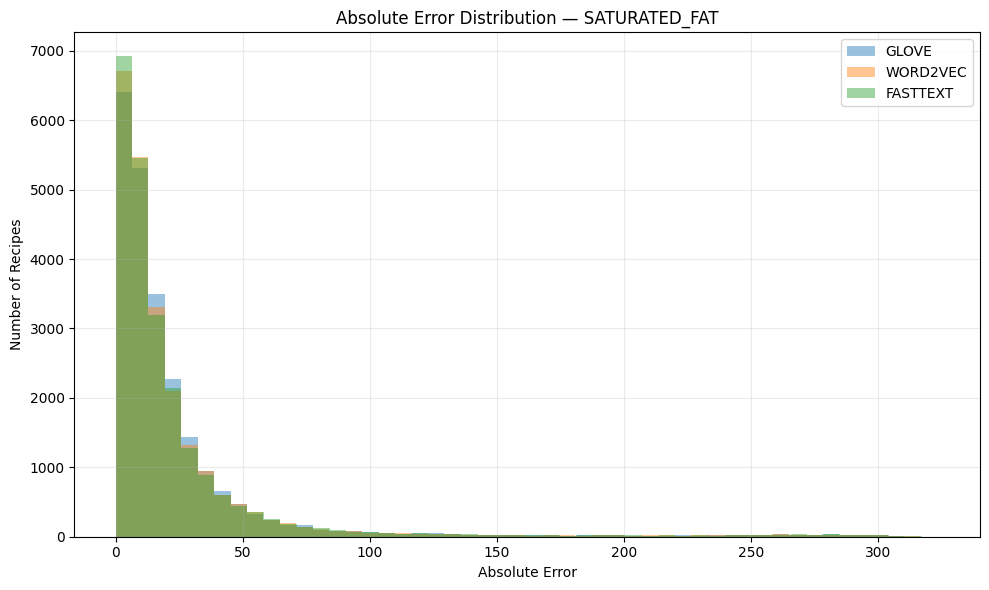

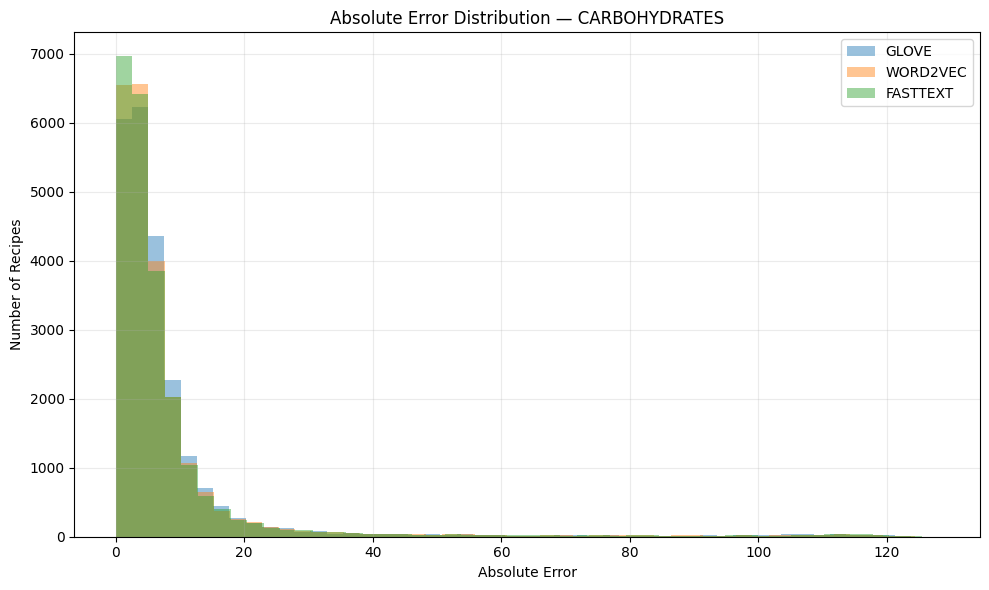

In [23]:
# ============================================================
# GRAPH 4 — ABSOLUTE ERROR DISTRIBUTION
# Full TEST SET
# ============================================================

for nutrient_idx, nutrient in enumerate(NUTRIENT_COLS):

    plt.figure(figsize=(10, 6))

    for model_name, predictions in all_predictions.items():

        errors = np.abs(
            y_true_original[:, nutrient_idx]
            - predictions[:, nutrient_idx]
        )

        plt.hist(
            errors,
            bins=50,
            alpha=0.45,
            label=model_name.upper()
        )

    plt.title(
        f"Absolute Error Distribution — {nutrient.upper()}"
    )

    plt.xlabel("Absolute Error")
    plt.ylabel("Number of Recipes")

    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

## Bonus: a simple "healthy recipe" classifier

The same nutrient columns can also be used for a lightweight classification side-experiment (not the core task, but a sanity check that the cleaned data behaves sensibly). All nutrient columns except calories are % Daily Value (PDV), so the "healthy" rule is defined accordingly.

Healthy
0    204729
1     25806
Name: count, dtype: int64


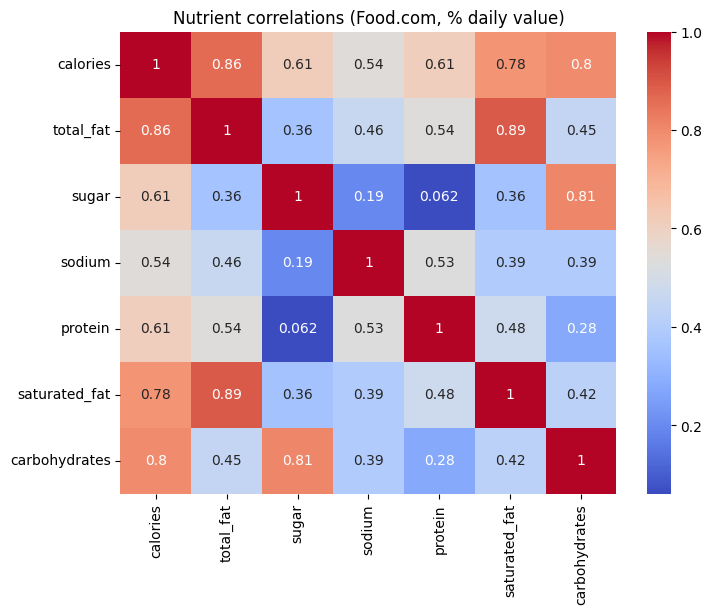

Logistic Regression:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     40946
           1       0.66      0.23      0.34      5161

    accuracy                           0.90     46107
   macro avg       0.78      0.61      0.64     46107
weighted avg       0.88      0.90      0.88     46107

Decision Tree:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     40946
           1       1.00      1.00      1.00      5161

    accuracy                           1.00     46107
   macro avg       1.00      1.00      1.00     46107
weighted avg       1.00      1.00      1.00     46107



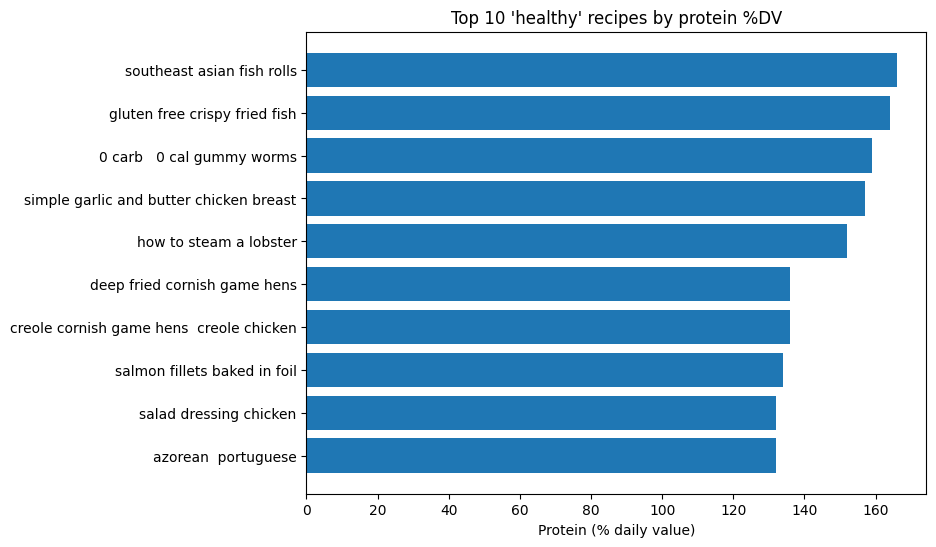

In [24]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

bonus_df = df[["name"] + NUTRIENT_COLS].copy()

# "Healthy" heuristic tuned for PDV-based nutrients: low calories, high
# protein %DV, low sugar %DV.
bonus_df["Healthy"] = np.where(
    (bonus_df["calories"] < 400) &
    (bonus_df["protein"] > 20) &
    (bonus_df["sugar"] < 20),
    1, 0,
)
print(bonus_df["Healthy"].value_counts())

plt.figure(figsize=(8, 6))
sns.heatmap(bonus_df[NUTRIENT_COLS].corr(), annot=True, cmap="coolwarm")
plt.title("Nutrient correlations (Food.com, % daily value)")
plt.show()

Xc = bonus_df[NUTRIENT_COLS]
yc = bonus_df["Healthy"]
Xc_train, Xc_test, yc_train, yc_test = tts(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)
print("Logistic Regression:\n", classification_report(yc_test, log_reg.predict(Xc_test), zero_division=0))

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(Xc_train, yc_train)
print("Decision Tree:\n", classification_report(yc_test, tree.predict(Xc_test), zero_division=0))

top_healthy = bonus_df[bonus_df["Healthy"] == 1].sort_values("protein", ascending=False).head(10)
plt.figure(figsize=(8, 6))
plt.barh(top_healthy["name"], top_healthy["protein"])
plt.xlabel("Protein (% daily value)")
plt.title("Top 10 'healthy' recipes by protein %DV")
plt.gca().invert_yaxis()
plt.show()


# Interactive Demo

In [ ]:
import re
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

with open(os.path.join(BASE_DIR, "tokenizer_v2.pkl"), "rb") as f:
    demo_tokenizer = pickle.load(f)
with open(os.path.join(BASE_DIR, "target_scaler.pkl"), "rb") as f:
    demo_scaler = pickle.load(f)
with open(os.path.join(BASE_DIR, "config_v2.pkl"), "rb") as f:
    demo_config = pickle.load(f)

demo_models = {}
for name in ["glove", "word2vec", "fasttext"]:
    path = os.path.join(BASE_DIR, f"{name}_bilstm_v2.keras")
    if os.path.exists(path):
        demo_models[name] = load_model(path, compile=False)

assert demo_models, (
    "No trained v2 models found in BASE_DIR. Run the fine-tuning (v2) "
    "cells in the 'Model Training' section above at least once first."
)

def predict_nutrition(food_description, model_choice):
    cleaned = clean_text_v2(food_description)
    seq = demo_tokenizer.texts_to_sequences([cleaned])
    seq = pad_sequences(seq, maxlen=demo_config["MAX_LEN"], padding="post", truncating="post")

    model = demo_models[model_choice]
    pred_scaled = model.predict(seq, verbose=0)
    pred = demo_scaler.inverse_transform(pred_scaled)[0]
    pred = np.clip(pred, a_min=0, a_max=None)  # nutrients can't be negative

    labels = ["Calories (kcal)", "Total Fat (%DV)", "Sugar (%DV)", "Sodium (%DV)",
              "Protein (%DV)", "Saturated Fat (%DV)", "Carbohydrates (%DV)"]
    return pd.DataFrame({"Nutrient": labels, "Predicted value": np.round(pred, 1)})

gr.Interface(
    fn=predict_nutrition,
    inputs=[
        gr.Textbox(
            label="Food description",
            placeholder="e.g. Grilled chicken breast with olive oil, garlic, and roasted vegetables",
            lines=3,
        ),
        gr.Dropdown(choices=list(demo_models.keys()), value=list(demo_models.keys())[0], label="Model (fine-tuned, v2)"),
    ],
    outputs=gr.Dataframe(headers=["Nutrient", "Predicted value"], label="Predicted nutrition"),
    title="Nutrition Information Extraction from Food Descriptions",
    description="Enter a free-text description of a dish (name + ingredients + steps works best) and pick a fine-tuned (v2) model to predict its nutritional profile.",
    examples=[
        ["Chocolate chip cookies with butter, sugar, flour, and chocolate chips", "glove"],
        ["Grilled salmon with lemon, olive oil, and steamed broccoli", "word2vec"],
        ["Deep fried chicken wings with hot sauce and butter", "fasttext"],
    ],
).launch(share=True)
